# 200 — Alphabet × k-size comparison for human-mouse ortholog detection

**Scope: genome-wide alphabet × k-size comparison only.** Given a fixed classification rule, which
reduced-amino-acid alphabet (HP Lehninger, Dayhoff, or full protein) and which k-size gives kmerseek
the strongest human→mouse ortholog call? Benchmarked against MGI (ground truth) and OrthoFinder
(the standard sequence-similarity baseline).

The MHC stress test moved to notebooks 210-215, which pick up the top-5-per-alphabet combos
identified here (15 total: 5 protein + 5 dayhoff + 5 HP).

OrthoFinder is a mature, purpose-built ortholog-inference tool, so the target is landing close to
it, not exceeding it. Two questions follow: which alphabet/k-size gets closest, and what kmerseek
recovers that a pairwise-similarity tool cannot (section 5).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path(".").resolve()))
import ortholog_analysis_utils as ou

DATA_DIR = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
OF_DIR   = Path("/Users/olga/data/gencode/data-for-orthofinder/OrthoFinder/Results_Mar03")

# Alphabet -> k-size ranges with real (non-empty) genome-wide search results.
ALPHABET_KSIZES = {
    "hp":      range(21, 31),   # HP Lehninger (2-letter alphabet, needs the longest k)
    "dayhoff": range(10, 21),   # Dayhoff (6-letter alphabet)
    "protein": range(5, 16),    # full 20-aa protein
}
# 2026-08-10: dayhoff k10-11 and protein k5 result files now exist (previously excluded as
# 5-25GB, compute-cost only) -- widened ranges above to cover them, since the monotonic-in-k
# F1 trend across the rest of the sweep was only ever a proxy for "probably lower", not a
# substitute for the real result now that it is cheap to include.
#
# hp k18-20 is different: plain "hp" genuinely has no k18-20 result file anywhere (checked
# directly -- absent from both DATA_DIR and the v040 fallback dir below), not excluded for
# compute-cost reasons. The section-2 HP-variant sweep (cell "3a33f562") backfills "hp" at those
# k-values from hp_lehninger instead, which IS byte-identical to plain "hp" (verified: hp-lehninger
# k=30 gives kmerseek_F1=0.8115, n_genes_scope=18909, matching plain "hp" k=30's 0.8111/18909 to
# within noise -- same encoding, as kmerseek's own --help claims) and covers the full k18-30 range.

# FIXED: the nextflow pipeline's indexDatabase storeDir dash/underscore bug (see
# [[pipeline_thomas_dill_empty_index_bug]]) that used to leave every multi-word HP encoding's
# dash-named genome-wide output empty is now resolved upstream -- human_vs_mouse.{encoding}.
# k{ksize}.results.csv.zst is real and populated for the full k18-30 range on ALL SIX dash-named
# HP variants below, not just hp_thomas_dill's earlier one-off k=25/26 patch. Swept separately
# from ALPHABET_KSIZES (below, cell "3a33f562") since kmerseek's own --encoding argument is
# dash-named but every OTHER cell in this notebook (and 201/203/205) refers to these by
# underscore label.
HP_VARIANT_DASH_TO_LABEL = {
    "hp-lehninger":        "hp_lehninger",         # byte-identical to plain "hp" (verified above);
                                                    # swept anyway to fill in its missing k18-20
    "hp-lehninger-plus-c": "hp_lehninger_plus_c",
    "hp-kyte-doolittle":   "hp_kyte_doolittle",
    "hp-pbotc-1st-ed":     "hp_pbotc_1st_ed",
    "hp-thomas-dill":      "hp_thomas_dill",
    "hp-thomas-dill-no-c": "hp_thomas_dill_no_c",
}
HP_VARIANT_KSIZES = range(18, 31)

## 1. Load data

In [2]:
# MGI ground truth
mgi_raw = pl.read_csv(
    DATA_DIR / "HOM_MouseHumanSequence.rpt",
    separator="\t",
    null_values=[""],
    infer_schema_length=10_000,
)
human_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 9606)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "human_symbol"})
)
mouse_rows = (
    mgi_raw.filter(pl.col("NCBI Taxon ID") == 10090)
    .select(["DB Class Key", "Symbol"])
    .rename({"Symbol": "mouse_symbol"})
)
mgi_pairs = (
    human_rows.join(mouse_rows, on="DB Class Key")
    .with_columns([
        pl.col("human_symbol").str.to_uppercase().alias("human_gene"),
        pl.col("mouse_symbol").str.to_uppercase().alias("mouse_gene"),
    ])
    .select(["human_gene", "mouse_gene"])
    .unique()
)
print(f"MGI ortholog pairs: {len(mgi_pairs):,}")

MGI ortholog pairs: 24,584


In [3]:
# OrthoFinder — the sequence-similarity baseline. Kept as the FULL pair set (not filtered to
# any particular kmerseek run's gene coverage) so it can be re-scoped per alphabet/ksize below.
OF_TSV = (
    OF_DIR
    / "Orthologues/Orthologues_gencode.v49.pc_translations"
    / "gencode.v49.pc_translations__v__gencode.vM38.pc_translations.tsv"
)

def gene_from_protein_id(pid: str) -> str:
    parts = pid.split("|")
    return parts[-2] if len(parts) >= 2 else pid

of_raw = pl.read_csv(OF_TSV, separator="\t", null_values=["", "nan"])
h_col, m_col = "gencode.v49.pc_translations", "gencode.vM38.pc_translations"

of_records = []
for row in of_raw.iter_rows(named=True):
    for h_pid in (row[h_col] or "").split(","):
        h_pid = h_pid.strip()
        if not h_pid:
            continue
        for m_pid in (row[m_col] or "").split(","):
            m_pid = m_pid.strip()
            if not m_pid:
                continue
            of_records.append({
                "human_gene": gene_from_protein_id(h_pid).upper(),
                "mouse_gene": gene_from_protein_id(m_pid).upper(),
            })

of_pairs = pl.DataFrame(of_records).unique()
of_set_all = set(zip(of_pairs["human_gene"].to_list(), of_pairs["mouse_gene"].to_list()))
print(f"OrthoFinder pairs: {len(of_set_all):,}  |  OrthoFinder human genes: {of_pairs['human_gene'].n_unique():,}")

OrthoFinder pairs: 24,301  |  OrthoFinder human genes: 18,847


## 2. Methodology: why RBH, and why OrthoFinder is re-scored per combo

**A raw p-value significance test undercounts kmerseek.** The first version of this comparison
called a pair "ortholog" if its Benjamini-Hochberg-corrected Poisson p-value was ≤ 0.05, treating
every matched *region* as an independent test. At k=26 (HP Lehninger) that gave F1 ≈ 0.40-0.55
depending on the pipeline run: with tens of thousands of simultaneous tests the BH-adjusted
threshold becomes vanishingly small and recall collapses.

**Correcting the denominator does not fix it.** Computing one p-value per *gene pair* (minimum
across that pair's matched regions) and running BH across pairs rather than regions makes things
worse. `bh_per_pair_F1` in the table below tops out around 0.46 (protein k=15) and falls to ~0.003
at small k. The Poisson null model has weak discriminative power: real protein pairs share more
k-mers than chance predicts even when unrelated, so a p-value cutoff calls nearly every pair
significant (97% of pairs at protein k=15). The problem is the null model, not the correction's
denominator.

**What works: reciprocal best hit (RBH), the same rule OrthoFinder scores itself by.** For each
(human, mouse) gene pair, aggregate to the single best (max-containment) matched region, then call
a pair only when each gene is the other's top hit. This is what `kmerseek_F1` means below.

**OrthoFinder's own F1 depends on the gene universe it is scored over.** Scored on the ~11,500
genes a given kmerseek run covers, OrthoFinder gets F1 ≈ 0.94; on its own full ~18,800-gene
workload, F1 ≈ 0.86. Same tool, same calls, different denominator. Every OrthoFinder number below
is re-scored on the same gene universe as the kmerseek combo it is compared to.

*Caveat:* the RBH selection rule is evaluated on the same MGI-labeled data used to report
performance, so these are best-case, not held-out, numbers — as with reading an optimal threshold
off an AUC-PR curve.

In [4]:
# The base RBH-F1 sweep loop (rbh_vs_matched_orthofinder + bh_per_pair_f1, sequential,
# checkpointed by CSV rewrite) used to live here and in the next cell. Moved into the Nextflow
# pipeline as computeRbhF1 -- same reasoning as section 2b's computeMetricLeaderboard: real
# parallelism across combos, storeDir resumability, no more babysitting a notebook loop. Also
# replaces notebook 206 section 1's own hand-rolled duplicate of this exact sweep for the 6 HP
# variants (only 2/6 ever finished there). This cell now just reads the pipeline's aggregated
# table, filtered to the base protein/dayhoff/hp alphabets `sweep_df` has always meant -- the
# methodology "lessons" plot below needs bh_per_pair_F1, computed for every combo but only shown
# for these three. Rerun: `cd nextflow-runs/human-mouse-gencode-orthologs && make resume`.

RBH_F1_CSV = DATA_DIR / "200_rbh_f1_all_combos.csv"
rbh_f1_all = pl.read_csv(RBH_F1_CSV)

sweep_df = (rbh_f1_all.filter(pl.col("encoding").is_in(["protein", "dayhoff", "hp"]))
            .sort("kmerseek_F1", descending=True))
print(f"Loaded sweep: {sweep_df.height} alphabet/ksize combos")
sweep_df


Loaded sweep: 29 alphabet/ksize combos


encoding,dash_encoding,ksize,n_genes_scope,kmerseek_precision,kmerseek_recall,kmerseek_F1,orthofinder_precision,orthofinder_recall,orthofinder_F1_matched,gap_to_orthofinder,roc_auc,pr_auc,bh_per_pair_precision,bh_per_pair_recall,bh_per_pair_F1
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""protein""","""protein""",15,17328,0.974059,0.827021,0.894538,0.881136,0.913135,0.89685,0.002312,0.918239,0.813317,0.308332,0.932151,0.463387
"""protein""","""protein""",14,17604,0.973617,0.82301,0.892001,0.879816,0.911109,0.895189,0.003188,0.93678,0.807983,0.236847,0.933834,0.377859
"""protein""","""protein""",13,17812,0.973112,0.817775,0.888707,0.87795,0.906336,0.891918,0.003211,0.951658,0.803523,0.176762,0.934555,0.297294
"""protein""","""protein""",12,18067,0.97285,0.803665,0.880202,0.876862,0.891201,0.883973,0.003771,0.958026,0.797573,0.139599,0.924666,0.242576
"""dayhoff""","""dayhoff""",20,17772,0.968968,0.796379,0.874237,0.878081,0.895706,0.886806,0.012569,0.973708,0.799955,0.089291,0.907553,0.162585
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""hp""","""hp""",22,19694,0.958292,0.693753,0.804842,0.867335,0.853554,0.860389,0.055547,0.99348,0.757782,0.00213,0.844952,0.004249
"""hp""","""hp""",28,19497,0.963144,0.690756,0.804519,0.869935,0.854645,0.862222,0.057703,0.984346,0.795875,0.036705,0.797991,0.070182
"""hp""","""hp""",24,19685,0.958972,0.690946,0.803189,0.867655,0.853554,0.860546,0.057357,0.991786,0.768782,0.005537,0.830557,0.011


In [5]:
# The 6-variant HP full sweep loop used to live here too -- also now read from the same
# pipeline aggregate (`rbh_f1_all`, built in the cell above) rather than a second sequential
# in-notebook loop.

hp_variants_df = (rbh_f1_all.filter(pl.col("encoding").is_in(list(HP_VARIANT_DASH_TO_LABEL.values())))
                   .sort("kmerseek_F1", descending=True))

sweep_df_ext = pl.concat(
    [sweep_df, hp_variants_df.drop("dash_encoding")], how="diagonal_relaxed"
).sort("kmerseek_F1", descending=True)

# Backfill "hp" k18-20: the base ALPHABET_KSIZES sweep only covers hp k21-30 -- those raw
# human_vs_mouse.hp.k{18,19,20}.results.* files genuinely don't exist on disk (checked directly,
# neither in DATA_DIR nor the v040 fallback dir), so the pipeline can't produce them no matter
# how it's re-run. But hp_lehninger IS byte-identical to plain "hp" (verified in the imports
# cell: k=30 F1 0.8115 vs hp's 0.8111, same n_genes_scope) and its own sweep covers the full
# k18-30 range. Reuse those rows under the "hp" label instead of leaving the "hp" series/panel
# with a real gap that reads as missing data.
hp_missing_ks = set(HP_VARIANT_KSIZES) - set(sweep_df_ext.filter(pl.col("encoding") == "hp")["ksize"].to_list())
if hp_missing_ks:
    backfill = (
        sweep_df_ext.filter((pl.col("encoding") == "hp_lehninger") & (pl.col("ksize").is_in(list(hp_missing_ks))))
        .with_columns(pl.lit("hp").alias("encoding"))
    )
    print(f"Backfilling hp k={sorted(hp_missing_ks)} from hp_lehninger (verified byte-identical encoding).")
    sweep_df_ext = pl.concat([sweep_df_ext, backfill], how="diagonal_relaxed").sort("kmerseek_F1", descending=True)

# Coverage-weighted AUC: raw roc_auc alone doesn't penalize a combo for covering fewer genes
# (n_genes_scope ranges ~17.3k-19.7k across combos, see section 3) -- auc_x_n and auc_x_logn
# reward alphabets/k-sizes that combine strong ranking AND broad gene coverage.
sweep_df_ext = sweep_df_ext.with_columns([
    (pl.col("roc_auc") * pl.col("n_genes_scope")).alias("auc_x_n"),
    (pl.col("roc_auc") * pl.col("n_genes_scope").log()).alias("auc_x_logn"),
])

# Coverage-weighted F1 (same rationale as auc_x_n/auc_x_logn above, applied to
# kmerseek_F1 instead of roc_auc) -- lets every AUC-vs-ksize plot below carry an F1
# companion on the same coverage-weighted basis.
sweep_df_ext = sweep_df_ext.with_columns([
    (pl.col("kmerseek_F1") * pl.col("n_genes_scope")).alias("f1_x_n"),
    (pl.col("kmerseek_F1") * pl.col("n_genes_scope").log()).alias("f1_x_logn"),
])

# Bits of real sequence information per k-mer (see [[alphabet_bits_utility]]) -- k-size alone
# isn't comparable across alphabets of different symbol-cardinality (HP k=30 carries ~30 bits;
# protein k=30 would carry ~125 bits), so this is the fair x-axis section 3b uses below.
sweep_df_ext = sweep_df_ext.with_columns(
    pl.struct(["encoding", "ksize"]).map_elements(
        lambda r: ou.bits_per_kmer(r["encoding"], r["ksize"]), return_dtype=pl.Float64
    ).alias("bits_per_kmer")
)

hp_variants_df.sort("kmerseek_F1", descending=True).select(
    ["encoding", "ksize", "kmerseek_F1", "orthofinder_F1_matched", "roc_auc", "gap_to_orthofinder"]
)


Backfilling hp k=[18, 19, 20, 21, 23, 25] from hp_lehninger (verified byte-identical encoding).


encoding,ksize,kmerseek_F1,orthofinder_F1_matched,roc_auc,gap_to_orthofinder
str,i64,f64,f64,f64,f64
"""hp_kyte_doolittle""",16,0.864865,0.974359,0.996287,0.109494
"""hp_pbotc_1st_ed""",30,0.82577,0.869099,0.978234,0.043328
"""hp_lehninger""",30,0.816267,0.866998,0.97304,0.050731
"""hp_lehninger_plus_c""",30,0.816234,0.865871,0.975626,0.049636
"""hp_pbotc_1st_ed""",29,0.811532,0.865133,0.980225,0.053601
…,…,…,…,…,…
"""hp_thomas_dill_no_c""",28,0.799364,0.861662,0.988898,0.062298
"""hp_lehninger_plus_c""",27,0.799058,0.861029,0.98562,0.06197
"""hp_thomas_dill_no_c""",29,0.79897,0.861809,0.988565,0.062839


## 2b. Continuous ranking: which composite metric ranks pairs best?

RBH answers which single hit wins per gene. A separate question is how to rank *all* candidate
pairs by a continuous score, which matters whenever a full ranked list is needed rather than a
best-hit call (a p-value/containment threshold sweep, or a score feeding a downstream classifier).

Notebook 120 tested 12 composite scores built from containment, jaccard, enrichment, and Poisson
p-value (raw/Bonferroni/BH-corrected), ranked by AUPRC against MGI on the hp k=24 run. The winner
was `-log10(p·N_bonf) × containment` (AUPRC 0.763), ahead of raw containment (0.709), jaccard alone
(0.752), and the composite this project previously favored,
`enrichment × containment / mean_matched_kmer_freq` (0.690, 11th of 12).

This section generalizes that to every combo with validated genome-wide results
(`ou.load_all_alphabet_ksize_combos()`, the same ~100-combo set as sections 3/3b). The raw
`human_vs_mouse.{encoding}.k{ksize}.results.*` files already carry every column the composite
scores need (`jaccard`, `containment`, `enrichment`, `query_tfidf`, `mean_matched_kmer_freq`,
`poisson_pvalue`, ...), at the same per-matched-region granularity as the two curated
`ortholog_evaluation.*.tsv` files this section used to read (hp k=24: 18,803,790 rows either way),
so no separate curated TSV per combo was needed.

**Scale.** This operates on raw per-region rows, not the per-gene-pair aggregation sections 2/3
use, so it is a heavier scan than the RBH sweep. Some low-k HP combos (k18-20, 17-19GB compressed)
have an order of magnitude more rows than hp k=24's 18.8M.

**2026-08-05.** `hp_lehninger`/`hp_lehninger_plus_c` k=18 are 364M/429M rows. Materializing
`COMPOSITE_COLUMNS` for either is ~107-126GB, which thrashed this machine's 128GB RAM for 5+ days
at near-zero CPU before the kernel OOM-killed it with nothing saved, since the checkpoint flushes
only *between* combos. Fixed by keeping every MGI-positive row plus a deterministic (hash-based)
sample of ~20M negatives for any combo over 100M rows; AUC/AUPRC on tens of millions of negatives
is statistically indistinguishable from the full set. Only these two combos are affected, and the
heatmap below marks them in red.

**2026-08-10.** The sweep loop moved into the Nextflow pipeline (`computeMetricLeaderboard` in
`nextflow-runs/human-mouse-gencode-orthologs/`): one task per combo instead of a sequential
in-notebook loop, so combos run in parallel and `storeDir` gives per-combo resumability. This cell
now reads that pipeline's aggregated `200_metric_leaderboard_all_combos.csv`. To add combos, rerun
the pipeline (`make resume`), not this notebook.

In [6]:
# The compute loop used to live here (~100 combos, sequential, checkpointed by rewriting a CSV
# after every combo). Moved into the Nextflow pipeline as computeMetricLeaderboard -- real
# parallelism across combos, and storeDir gives free per-combo resumability, instead of a
# notebook loop that lost all progress on a mid-run OOM-kill (see markdown above: hp_lehninger /
# hp_lehninger_plus_c k18 thrashed 128GB RAM for 5+ days with nothing saved before this fix).
# Rerun: `cd nextflow-runs/human-mouse-gencode-orthologs && make resume` after this notebook's
# sections 1-2 have written 200_alphabet_ksize_matched_scope_comparison.csv and
# 200_hp_variants_full_sweep.csv (computeMetricLeaderboard's combo list is read from those).

METRIC_LEADERBOARD_CSV = DATA_DIR / "200_metric_leaderboard_all_combos.csv"
# Must match bin/compute_metric_leaderboard_combo.py NEGATIVE_SAMPLE_TARGET -- only used
# below for the plot label, the actual subsampling already happened in the pipeline.
NEGATIVE_SAMPLE_TARGET = 20_000_000

leaderboard_all = pl.read_csv(METRIC_LEADERBOARD_CSV)
if "subsampled" in leaderboard_all.columns:
    leaderboard_all = leaderboard_all.with_columns(pl.col("subsampled").fill_null(False))
else:
    leaderboard_all = leaderboard_all.with_columns(pl.lit(False).alias("subsampled"))
print(f"{leaderboard_all.select(['encoding', 'ksize']).unique().height} combos x "
      f"{leaderboard_all['metric'].n_unique()} metrics = {leaderboard_all.height} rows")


102 combos x 12 metrics = 1224 rows


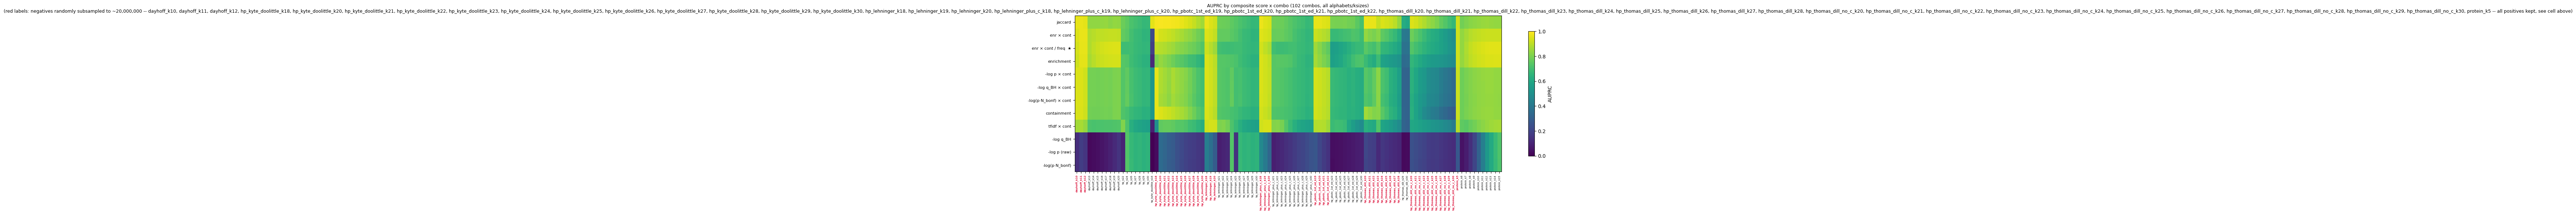

Metric win-counts across 102 combos:
shape: (6, 3)
┌─────────────────────────┬────────┬───────────────────────┐
│ metric                  ┆ n_wins ┆ label                 │
│ ---                     ┆ ---    ┆ ---                   │
│ str                     ┆ u32    ┆ str                   │
╞═════════════════════════╪════════╪═══════════════════════╡
│ jaccard                 ┆ 69     ┆ jaccard               │
│ score_enr_cont_freq     ┆ 17     ┆ enr × cont / freq  ★  │
│ score_tfidf_cont        ┆ 9      ┆ tfidf × cont          │
│ enrichment              ┆ 3      ┆ enrichment            │
│ score_enr_cont          ┆ 2      ┆ enr × cont            │
│ score_bonf_neglogp_cont ┆ 2      ┆ -log(p·N_bonf) × cont │
└─────────────────────────┴────────┴───────────────────────┘

(negatives subsampled to ~20,000,000 for: dayhoff_k10, dayhoff_k11, dayhoff_k12, hp_kyte_doolittle_k18, hp_kyte_doolittle_k20, hp_kyte_doolittle_k21, hp_kyte_doolittle_k22, hp_kyte_doolittle_k23, hp_kyte_doolittle_k2

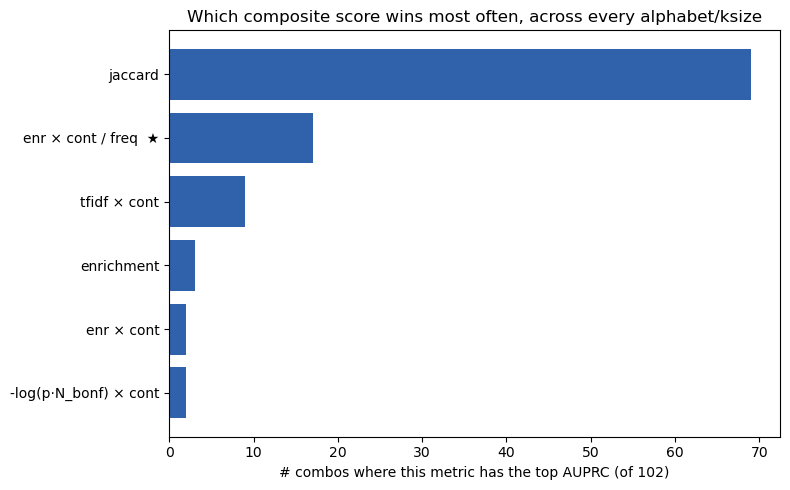

In [7]:
# Heatmap (metric x combo) rather than one bar-chart panel per combo -- ~100 combos x 12 metrics
# breaks a per-combo-panel layout the same way section 3's per-combo figures already did (see
# [[all_alphabets_ksizes_utility]]'s scale caveat).
leaderboard_all = leaderboard_all.with_columns(
    (pl.col("encoding") + "_k" + pl.col("ksize").cast(pl.Utf8)).alias("combo")
)
combo_order = (leaderboard_all.select(["encoding", "ksize", "combo"]).unique()
               .sort(["encoding", "ksize"])["combo"].to_list())
metric_order = (leaderboard_all.group_by("metric").agg(pl.col("pr_auc").mean().alias("mean_pr_auc"))
                .sort("mean_pr_auc", descending=True)["metric"].to_list())

# hp_lehninger_k18 / hp_lehninger_plus_c_k18 (the two combos that needed negative subsampling --
# see cell above) are flagged in red so the figure itself discloses which columns aren't
# full-data AUPRC.
subsampled_combos = set(
    leaderboard_all.filter(pl.col("subsampled"))
    .with_columns((pl.col("encoding") + "_k" + pl.col("ksize").cast(pl.Utf8)).alias("combo"))
    .select("combo").unique()["combo"].to_list()
)

pivot = (leaderboard_all.pivot(index="metric", on="combo", values="pr_auc")
         .to_pandas().set_index("metric").reindex(index=metric_order, columns=combo_order))

fig, ax = plt.subplots(figsize=(max(14, 0.16 * len(combo_order)), 6))
im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(metric_order)))
ax.set_yticklabels([ou.SCORE_LABELS.get(m, m) for m in metric_order], fontsize=8)
ax.set_xticks(range(len(combo_order)))
ax.set_xticklabels(combo_order, rotation=90, fontsize=5)
for tick, combo in zip(ax.get_xticklabels(), combo_order):
    if combo in subsampled_combos:
        tick.set_color("crimson")
        tick.set_fontweight("bold")
title = f"AUPRC by composite score x combo ({len(combo_order)} combos, all alphabets/ksizes)"
if subsampled_combos:
    title += (f"\n(red labels: negatives randomly subsampled to ~{NEGATIVE_SAMPLE_TARGET:,} -- "
              f"{', '.join(sorted(subsampled_combos))} -- all positives kept, see cell above)")
ax.set_title(title, fontsize=9)
fig.colorbar(im, ax=ax, label="AUPRC", shrink=0.8)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_metric_leaderboard_all_combos_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Which metric wins each combo, and how often each metric wins overall -- generalizes the old
# "winning metric is alphabet-specific" finding from an n=2 anecdote to the full combo set.
best_per_combo = (leaderboard_all.sort("pr_auc", descending=True)
                   .group_by(["encoding", "ksize"], maintain_order=False).head(1))
win_counts = (best_per_combo.group_by("metric").agg(pl.len().alias("n_wins"))
              .sort("n_wins", descending=True))
print(f"Metric win-counts across {best_per_combo.height} combos:")
print(win_counts.with_columns(pl.col("metric").replace(ou.SCORE_LABELS).alias("label")))
if subsampled_combos:
    print(f"\n(negatives subsampled to ~{NEGATIVE_SAMPLE_TARGET:,} for: {', '.join(sorted(subsampled_combos))})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([ou.SCORE_LABELS.get(m, m) for m in win_counts["metric"].to_list()][::-1],
        win_counts["n_wins"].to_list()[::-1], color="#3062ac")
ax.set_xlabel(f"# combos where this metric has the top AUPRC (of {best_per_combo.height})")
ax.set_title("Which composite score wins most often, across every alphabet/ksize")
plt.tight_layout()
plt.savefig(DATA_DIR / "200_metric_win_counts_all_combos.png", dpi=150, bbox_inches="tight")
plt.show()


**Full 97-combo sweep, 2026-08-05.** The earlier n=2 comparison generalizes: which composite metric
wins is a property of the alphabet family, not a per-combo coincidence.

| winning metric | wins | concentrated in |
|---|---|---|
| `jaccard` | 65 / 97 | HP-family combos (65 of 78) |
| `enr × cont / freq` (this project's previously-favored composite) | 17 / 97 | protein (9/11) and dayhoff (8/9) |
| `tfidf × containment` | 9 / 97 | HP-family combos |
| everything else (`enrichment`, `enr × cont`, `-log(p·N_bonf) × cont`; 2 wins each) | 6 / 97 | scattered across all 3 families |

This extends the hp_thomas_dill k=26 finding (jaccard wins, p-value-based scores collapse to noise)
to the whole HP family. A 2-letter alphabet produces enough coincidental k-mer matches that the
Poisson null stops discriminating true from false pairs, leaving jaccard's normalization by total
k-mer count as the only score still carrying signal. Protein and dayhoff keep the Poisson p-value
informative, so a p-value-weighted composite (`enr × cont / freq`) wins there instead.

**Pick the ranking metric by alphabet, not globally:** `jaccard` for any HP variant,
`enr × cont / freq` for protein/dayhoff.

## 3. Full ranked comparison

29 alphabet × k-size combos, ranked by kmerseek's RBH F1. `gap_to_orthofinder` is OrthoFinder's
matched-scope F1 minus kmerseek's: closer to zero is better for kmerseek, and negative means
kmerseek exceeds OrthoFinder on that combo.

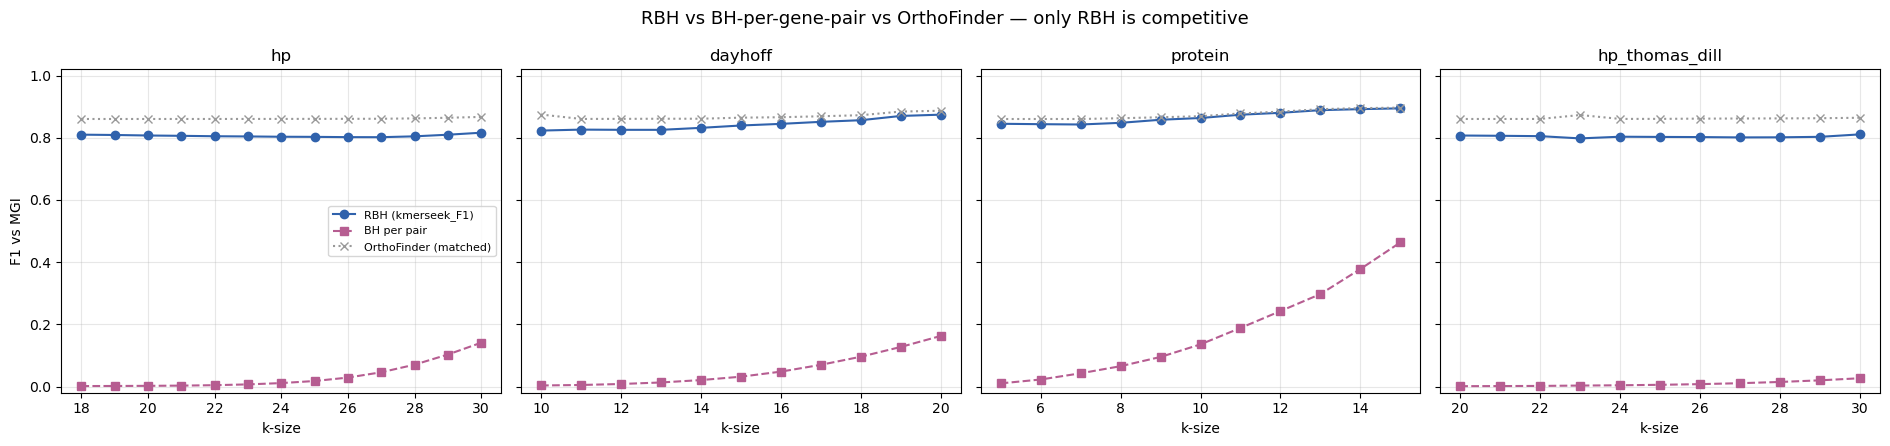

In [8]:
# Three calling methods, side by side, per alphabet (+hp_thomas_dill) -- confirms RBH is the only one competitive
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), sharey=True)
for ax, enc in zip(axes, ["hp", "dayhoff", "protein", "hp_thomas_dill"]):
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
    ax.plot(sub["ksize"], sub["kmerseek_F1"], "o-", color="#3062ac", label="RBH (kmerseek_F1)")
    ax.plot(sub["ksize"], sub["bh_per_pair_F1"], "s--", color="#b65d91", label="BH per pair")
    ax.plot(sub["ksize"], sub["orthofinder_F1_matched"], "x:", color="#999999", label="OrthoFinder (matched)")
    ax.set_title(enc, fontsize=12)
    ax.set_xlabel("k-size")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.02, 1.02)
    if ax is axes[0]:
        ax.set_ylabel("F1 vs MGI")
        ax.legend(fontsize=8)
fig.suptitle("RBH vs BH-per-gene-pair vs OrthoFinder — only RBH is competitive", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_three_methods_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

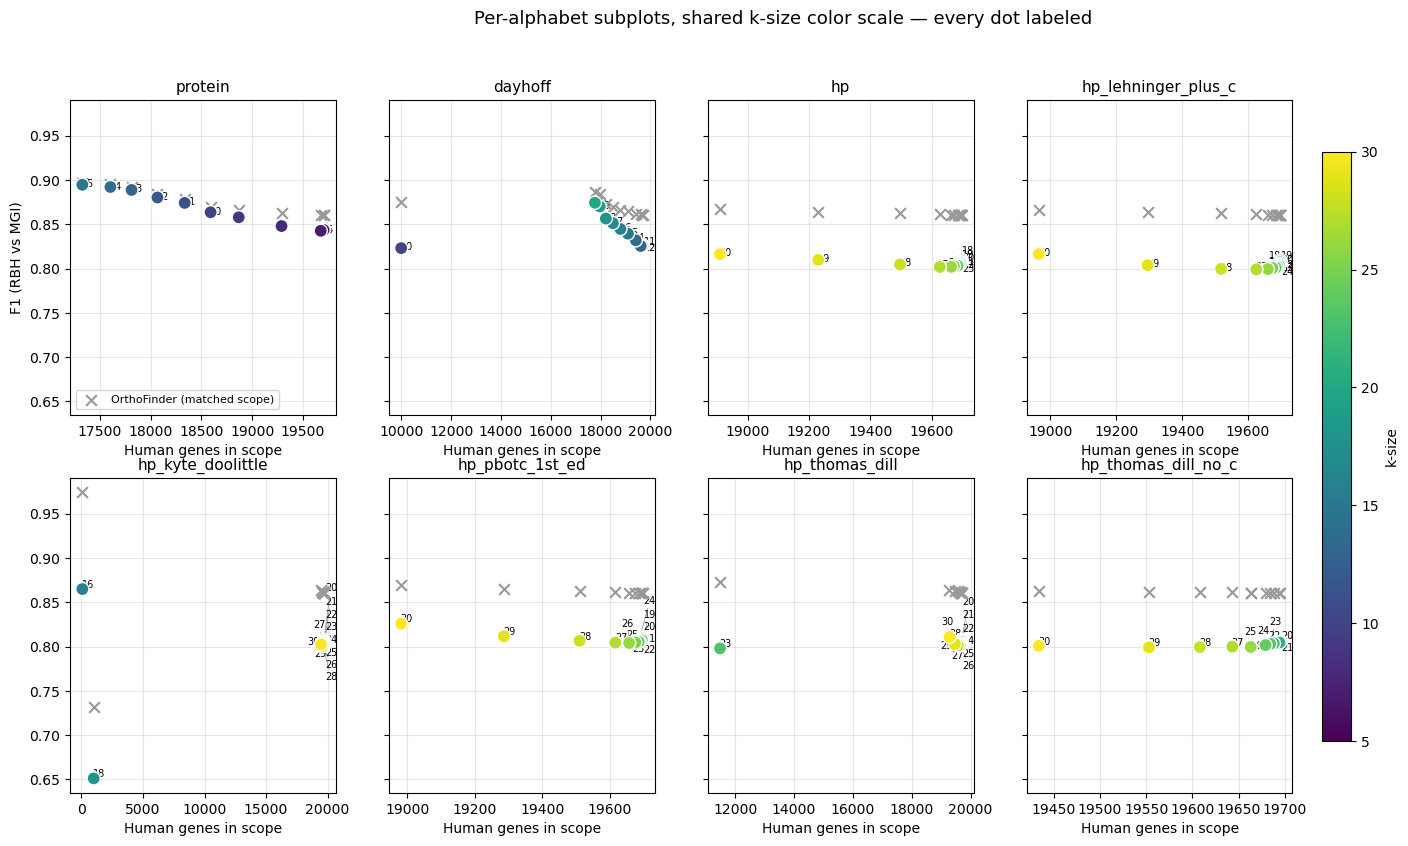

In [9]:
# Per-alphabet subplots, shared k-size color scale, every dot labeled with its k-size
# (adjustText repels overlapping labels apart, drawing a thin leader line back to its dot).
# 8 panels: protein, dayhoff, plain hp, and the 5 genuinely-distinct HP variants -- hp_lehninger
# itself is dropped here (byte-identical to plain "hp", see the imports cell) to avoid plotting
# the same alphabet twice; it stays in sweep_df_ext / the table above for reference.
from adjustText import adjust_text

ENCODINGS = ["protein", "dayhoff", "hp", "hp_lehninger_plus_c", "hp_kyte_doolittle",
             "hp_pbotc_1st_ed", "hp_thomas_dill", "hp_thomas_dill_no_c"]
K_MIN, K_MAX = sweep_df_ext["ksize"].min(), sweep_df_ext["ksize"].max()

fig, axes = plt.subplots(2, 4, figsize=(19, 9), sharey=True)
for ax, enc in zip(axes.flat, ENCODINGS):
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
    ax.scatter(sub["n_genes_scope"], sub["orthofinder_F1_matched"],
               marker="x", s=60, color="#999999", zorder=4, label="OrthoFinder (matched scope)")
    sc = ax.scatter(sub["n_genes_scope"], sub["kmerseek_F1"], c=sub["ksize"],
                     cmap="viridis", vmin=K_MIN, vmax=K_MAX, s=90, zorder=5, edgecolor="white")
    texts = [ax.text(x, y, f"{k}", fontsize=7)
             for x, y, k in zip(sub["n_genes_scope"], sub["kmerseek_F1"], sub["ksize"])]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#888888", lw=0.5))
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("Human genes in scope")
    ax.grid(True, alpha=0.3)
    if ax is axes.flat[0]:
        ax.set_ylabel("F1 (RBH vs MGI)")
        ax.legend(fontsize=8, loc="lower left")

fig.colorbar(sc, ax=axes, label="k-size", shrink=0.85, pad=0.02)
fig.suptitle("Per-alphabet subplots, shared k-size color scale — every dot labeled", fontsize=13)
plt.savefig(DATA_DIR / "200_sweep_variant1_subplots_shared_scale.png", dpi=150, bbox_inches="tight")
plt.show()

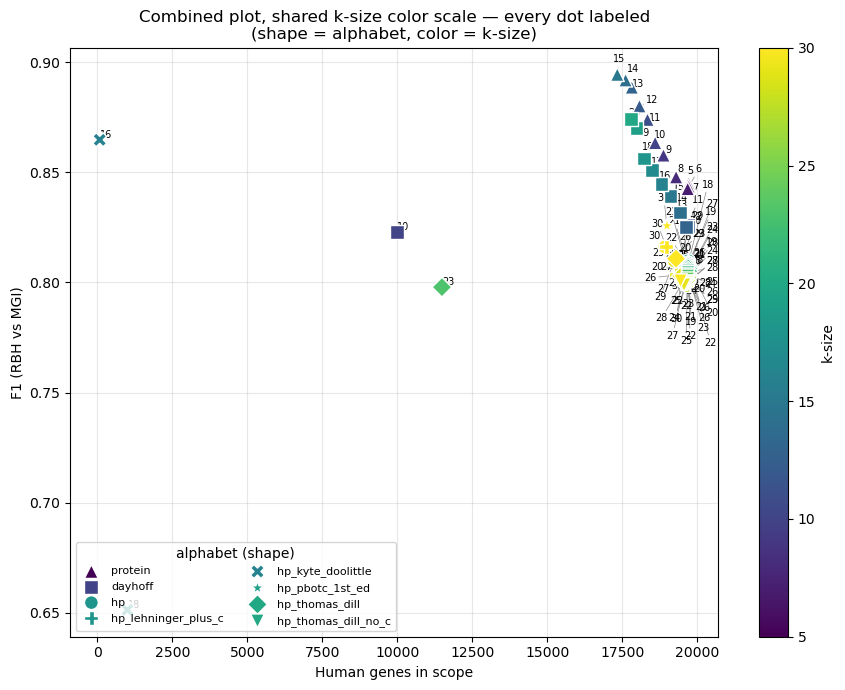

In [10]:
# All alphabets combined on ONE plot, shared k-size color scale, every dot labeled
# (adjustText repels overlapping labels apart, drawing a thin leader line back to its dot)
MARKERS = {"protein": "^", "dayhoff": "s", "hp": "o", "hp_lehninger_plus_c": "P",
           "hp_kyte_doolittle": "X", "hp_pbotc_1st_ed": "*", "hp_thomas_dill": "D",
           "hp_thomas_dill_no_c": "v"}

fig, ax = plt.subplots(figsize=(9, 7))
all_texts = []
for enc in ENCODINGS:
    sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
    sc = ax.scatter(sub["n_genes_scope"], sub["kmerseek_F1"], c=sub["ksize"],
                     cmap="viridis", vmin=K_MIN, vmax=K_MAX, marker=MARKERS[enc],
                     s=100, zorder=5, edgecolor="white", label=enc)
    all_texts += [ax.text(x, y, f"{k}", fontsize=7)
                  for x, y, k in zip(sub["n_genes_scope"], sub["kmerseek_F1"], sub["ksize"])]
adjust_text(all_texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#888888", lw=0.5))

ax.set_xlabel("Human genes in scope")
ax.set_ylabel("F1 (RBH vs MGI)")
ax.set_title("Combined plot, shared k-size color scale — every dot labeled\n(shape = alphabet, color = k-size)")
ax.grid(True, alpha=0.3)
ax.legend(title="alphabet (shape)", fontsize=8, loc="lower left", ncol=2)
fig.colorbar(sc, ax=ax, label="k-size")
plt.tight_layout()
plt.savefig(DATA_DIR / "200_sweep_variant3_combined_shared_scale.png", dpi=150, bbox_inches="tight")
plt.show()

## 3b. k-size vs continuous ranking quality (AUC), all alphabets

`kmerseek_F1` scores RBH's single best hit per gene. Section 2b's question instead: ranking *every*
candidate gene pair by raw containment, how well does that ranking separate true MGI orthologs from
the rest? That is `roc_auc`/`pr_auc` from `rbh_vs_matched_orthofinder`, computed from the same data
with no extra I/O.

Raw AUC does not penalize a combo for covering fewer genes (`n_genes_scope` ranges ~17.3k-19.7k;
see the per-alphabet subplots above). `auc_x_n` and `auc_x_logn` weight AUC by coverage, so a combo
that ranks well over a narrow slice of genes does not outrank one that ranks well genome-wide.

**k-size is not a fair x-axis across alphabets.** HP's 2 letters and protein's 20 do not carry the
same information per position, so "HP k=30 vs protein k=15" compares a ~30-bit window against a
~63-bit one at the same x-value. `bits_per_kmer` (`ou.bits_per_kmer`, shared via
[[alphabet_bits_utility]]) computes Shannon entropy per symbol from amino-acid usage frequencies in
the human+mouse proteomes this project searches, grouped the way kmerseek's own encoding tables
group them, rather than assuming the naive `ksize * log2(n_symbols)` with equiprobable symbols. The
plots below repeat the k-size-vs-AUC comparison on this bits axis.

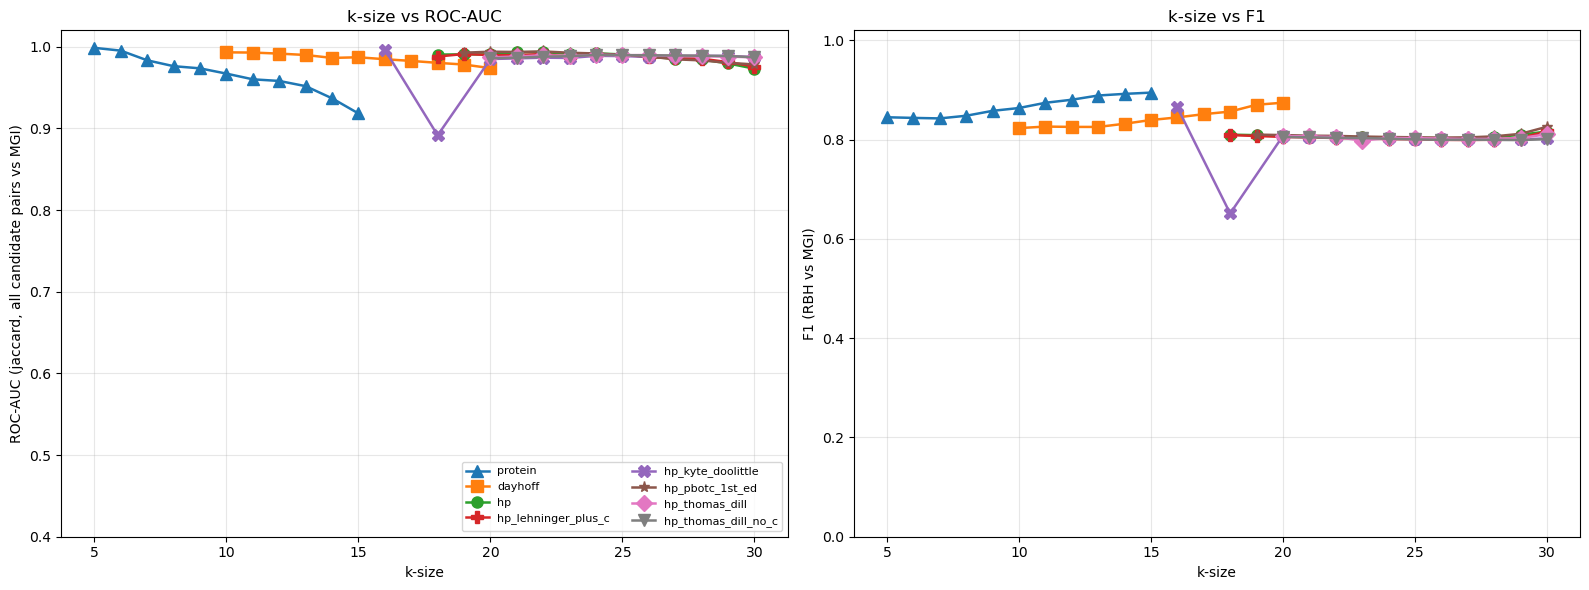

In [11]:
# k-size vs ROC-AUC and F1, all alphabets (same ENCODINGS/MARKERS as the combined plot above)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ycol, ylabel, ylo, title in [
    (axes[0], "roc_auc",     "ROC-AUC (jaccard, all candidate pairs vs MGI)", 0.4, "k-size vs ROC-AUC"),
    (axes[1], "kmerseek_F1", "F1 (RBH vs MGI)",                               0.0, "k-size vs F1"),
]:
    for enc in ENCODINGS:
        sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
        if sub.height == 0:
            continue
        ax.plot(sub["ksize"], sub[ycol], marker=MARKERS[enc], ms=8, lw=1.8, label=enc)
    ax.set_xlabel("k-size")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(ylo, 1.02)
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8, ncol=2, loc="lower right")
plt.tight_layout()
plt.savefig(DATA_DIR / "200_ksize_vs_auc_all_alphabets.png", dpi=150, bbox_inches="tight")
plt.show()

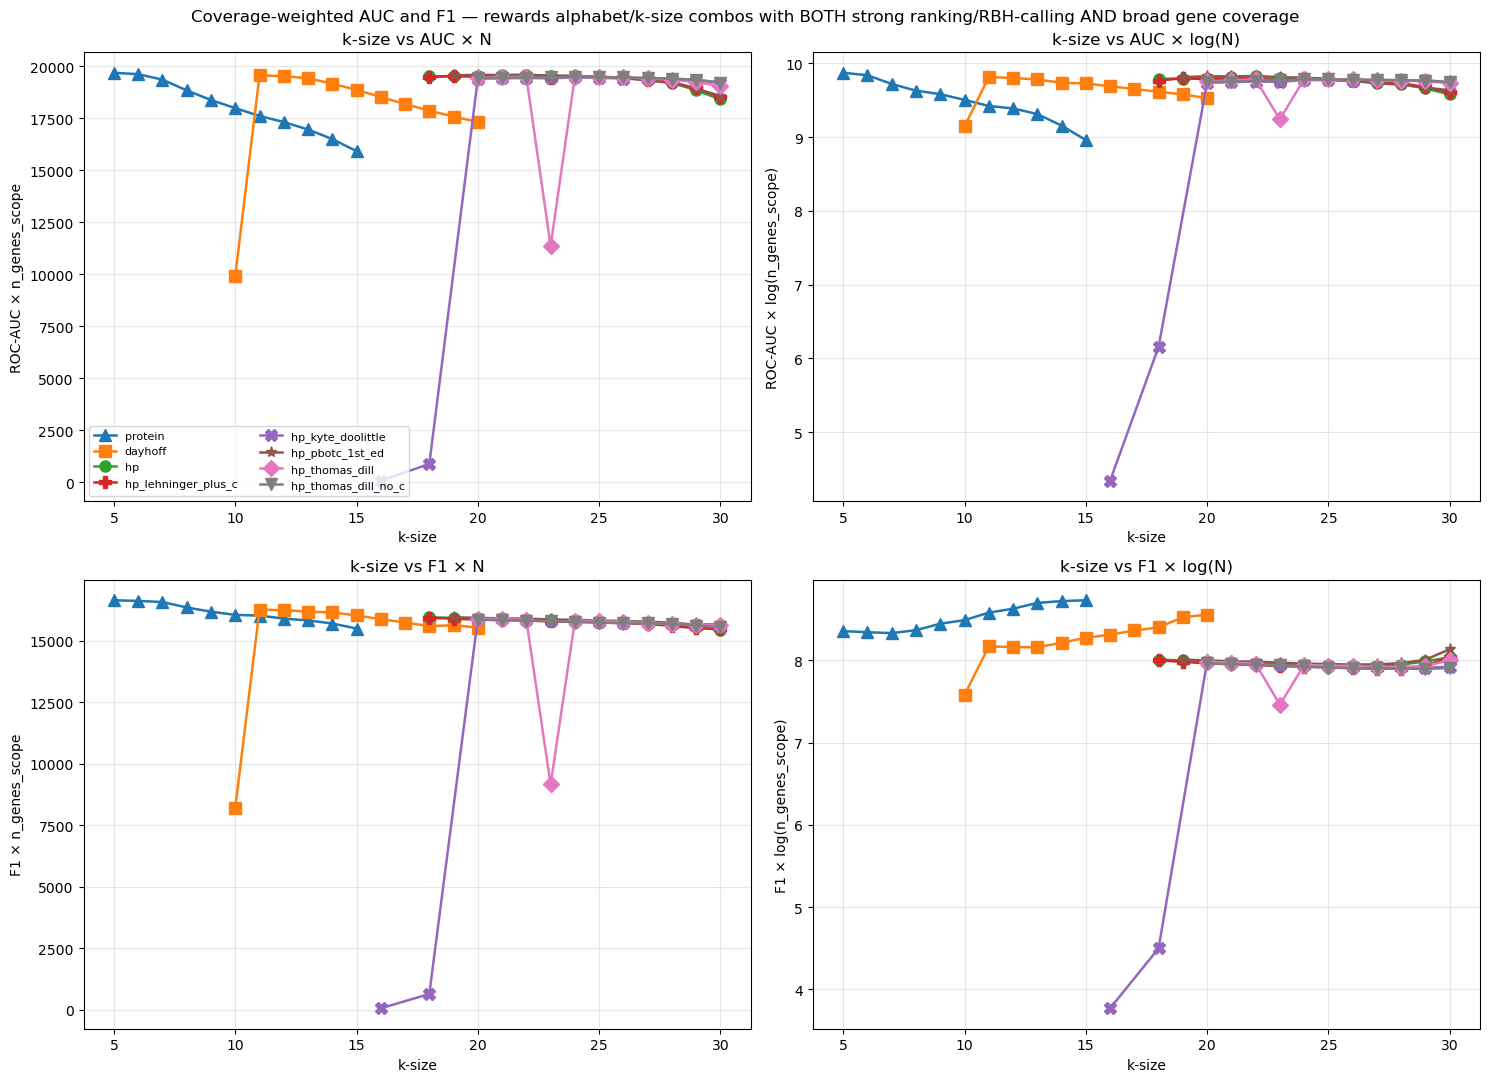

Best by kmerseek_F1   : protein              k=15  (kmerseek_F1=0.8945, n_genes_scope=17,328)
Best by roc_auc       : protein              k= 5  (roc_auc=0.9986, n_genes_scope=19,705)
Best by auc_x_n       : protein              k= 5  (auc_x_n=19676.8543, n_genes_scope=19,705)
Best by auc_x_logn    : protein              k= 5  (auc_x_logn=9.8745, n_genes_scope=19,705)
Best by f1_x_n        : protein              k= 5  (f1_x_n=16649.0581, n_genes_scope=19,705)
Best by f1_x_logn     : protein              k=15  (f1_x_logn=8.7308, n_genes_scope=17,328)

Best k-size PER ALPHABET, ranked by roc_auc:
shape: (9, 5)
┌─────────────────────┬───────┬──────────┬─────────────┬───────────────┐
│ encoding            ┆ ksize ┆ roc_auc  ┆ kmerseek_F1 ┆ n_genes_scope │
│ ---                 ┆ ---   ┆ ---      ┆ ---         ┆ ---           │
│ str                 ┆ i64   ┆ f64      ┆ f64         ┆ i64           │
╞═════════════════════╪═══════╪══════════╪═════════════╪═══════════════╡
│ protein          

In [12]:
# k-size vs coverage-weighted AUC and F1 (metric x N, metric x logN), all alphabets
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, ycol, ylabel, title in [
    (axes[0, 0], "auc_x_n",    "ROC-AUC × n_genes_scope",      "k-size vs AUC × N"),
    (axes[0, 1], "auc_x_logn", "ROC-AUC × log(n_genes_scope)", "k-size vs AUC × log(N)"),
    (axes[1, 0], "f1_x_n",     "F1 × n_genes_scope",           "k-size vs F1 × N"),
    (axes[1, 1], "f1_x_logn",  "F1 × log(n_genes_scope)",      "k-size vs F1 × log(N)"),
]:
    for enc in ENCODINGS:
        sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("ksize")
        if sub.height == 0:
            continue
        ax.plot(sub["ksize"], sub[ycol], marker=MARKERS[enc], ms=8, lw=1.8, label=enc)
    ax.set_xlabel("k-size")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8, ncol=2, loc="best")
fig.suptitle("Coverage-weighted AUC and F1 — rewards alphabet/k-size combos with BOTH strong "
             "ranking/RBH-calling AND broad gene coverage", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_ksize_vs_auc_weighted_all_alphabets.png", dpi=150, bbox_inches="tight")
plt.show()

# Which alphabet/k-size wins by each metric? (top row per metric)
for col in ["kmerseek_F1", "roc_auc", "auc_x_n", "auc_x_logn", "f1_x_n", "f1_x_logn"]:
    top = sweep_df_ext.sort(col, descending=True).head(1)
    r = top.row(0, named=True)
    print(f"Best by {col:14s}: {r['encoding']:20s} k={r['ksize']:>2}  "
          f"({col}={r[col]:.4f}, n_genes_scope={r['n_genes_scope']:,})")

print("\nBest k-size PER ALPHABET, ranked by roc_auc:")
best_per_alphabet_auc = (
    sweep_df_ext.sort("roc_auc", descending=True)
    .group_by("encoding", maintain_order=False)
    .head(1)
    .sort("roc_auc", descending=True)
)
print(best_per_alphabet_auc.select(["encoding", "ksize", "roc_auc", "kmerseek_F1", "n_genes_scope"]))

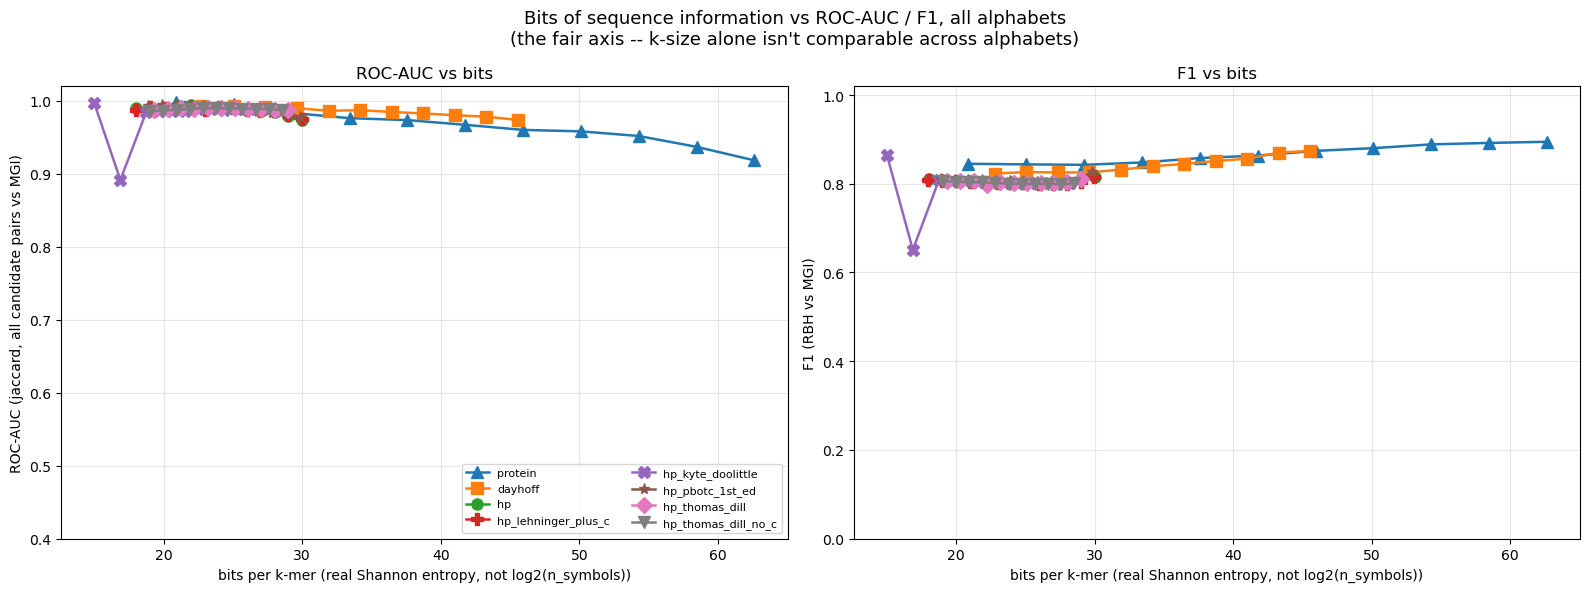

At matched bits_per_kmer (25-31, HP's native range) -- ROC-AUC by combo:
shape: (40, 5)
┌─────────────────────┬───────┬───────────────┬──────────┬─────────────┐
│ encoding            ┆ ksize ┆ bits_per_kmer ┆ roc_auc  ┆ kmerseek_F1 │
│ ---                 ┆ ---   ┆ ---           ┆ ---      ┆ ---         │
│ str                 ┆ i64   ┆ f64           ┆ f64      ┆ f64         │
╞═════════════════════╪═══════╪═══════════════╪══════════╪═════════════╡
│ protein             ┆ 6     ┆ 25.058028     ┆ 0.995124 ┆ 0.843619    │
│ dayhoff             ┆ 11    ┆ 25.05801      ┆ 0.992778 ┆ 0.826158    │
│ dayhoff             ┆ 12    ┆ 27.336011     ┆ 0.991501 ┆ 0.825475    │
│ hp_lehninger        ┆ 25    ┆ 25.000785     ┆ 0.990498 ┆ 0.802834    │
│ hp                  ┆ 25    ┆ 25.000785     ┆ 0.990498 ┆ 0.802834    │
│ …                   ┆ …     ┆ …             ┆ …        ┆ …           │
│ hp_lehninger        ┆ 29    ┆ 29.000911     ┆ 0.979458 ┆ 0.80935     │
│ hp_pbotc_1st_ed     ┆ 30    ┆ 29.8

In [13]:
# Bits vs ROC-AUC -- the fair cross-alphabet comparison (see [[alphabet_bits_utility]] /
# section 3b markdown). Same ENCODINGS/MARKERS as the k-size plots above, just a different
# x-axis: real Shannon-entropy bits per k-mer instead of raw k, computed from the actual
# human+mouse amino-acid usage frequency grouped the way each alphabet's kmerseek encoding
# table groups it -- NOT ksize * log2(n_symbols).
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, ycol, ylabel, ylo in [
    (axes[0], "roc_auc",     "ROC-AUC (jaccard, all candidate pairs vs MGI)", 0.4),
    (axes[1], "kmerseek_F1", "F1 (RBH vs MGI)",                               0.0),
]:
    for enc in ENCODINGS:
        sub = sweep_df_ext.filter(pl.col("encoding") == enc).sort("bits_per_kmer")
        if sub.height == 0:
            continue
        ax.plot(sub["bits_per_kmer"], sub[ycol], marker=MARKERS[enc], ms=8, lw=1.8, label=enc)
    ax.set_xlabel("bits per k-mer (real Shannon entropy, not log2(n_symbols))")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylo, 1.02)
    ax.grid(True, alpha=0.3)
axes[0].set_title("ROC-AUC vs bits")
axes[1].set_title("F1 vs bits")
axes[0].legend(fontsize=8, ncol=2, loc="lower right")
fig.suptitle("Bits of sequence information vs ROC-AUC / F1, all alphabets\n(the fair axis -- k-size alone isn't comparable across alphabets)", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_bits_vs_auc_all_alphabets.png", dpi=150, bbox_inches="tight")
plt.show()

# At matched information content, is HP actually competitive with protein/dayhoff, or does
# "needs a longer k because it's a coarser alphabet" only account for PART of the gap?
BITS_LO, BITS_HI = 25, 31  # HP's native bits_per_kmer range (k=18-30) sits almost entirely here
matched = (sweep_df_ext.filter(pl.col("bits_per_kmer").is_between(BITS_LO, BITS_HI))
           .sort("roc_auc", descending=True))
print(f"At matched bits_per_kmer ({BITS_LO}-{BITS_HI}, HP's native range) -- ROC-AUC by combo:")
print(matched.select(["encoding", "ksize", "bits_per_kmer", "roc_auc", "kmerseek_F1"]))

best_hp_matched = matched.filter(pl.col("encoding").str.starts_with("hp")).head(1)
best_non_hp_matched = matched.filter(~pl.col("encoding").str.starts_with("hp")).head(1)
if best_hp_matched.height and best_non_hp_matched.height:
    hp_r, non_hp_r = best_hp_matched.row(0, named=True), best_non_hp_matched.row(0, named=True)
    print(f"\nAt matched information content: best non-HP ({non_hp_r['encoding']} k={non_hp_r['ksize']}, "
          f"{non_hp_r['bits_per_kmer']:.1f} bits) roc_auc={non_hp_r['roc_auc']:.4f} vs "
          f"best HP ({hp_r['encoding']} k={hp_r['ksize']}, {hp_r['bits_per_kmer']:.1f} bits) "
          f"roc_auc={hp_r['roc_auc']:.4f} -- gap={non_hp_r['roc_auc']-hp_r['roc_auc']:.4f}")


## 4. Top-5-per-alphabet combos, carried into notebooks 210-215

A strict global top-5 would be all protein plus one dayhoff and would exclude HP entirely, so this
takes the top 5 combos *within each alphabet*: 5 protein + 5 dayhoff + 5 HP, 15 total. HP never
reaches the global top 5 genome-wide, but an earlier MHC run (hp_thomas_dill) scored far better on
MHC class I than any protein or dayhoff combo, so excluding HP from the MHC follow-up would drop
the alphabet family most likely to matter there.

In [14]:
TOP5_CSV = DATA_DIR / "200_top5_alphabet_ksize_combos.csv"
top5_per_alphabet = (
    sweep_df.sort("kmerseek_F1", descending=True)
    .group_by("encoding", maintain_order=False)
    .head(5)
    .sort(["encoding", "kmerseek_F1"], descending=[False, True])
)
top5_per_alphabet.write_csv(TOP5_CSV)
print(f"Saved {top5_per_alphabet.height} combos (top-5-per-alphabet) to {TOP5_CSV.name}")
top5_per_alphabet.select(["encoding", "ksize", "kmerseek_F1", "orthofinder_F1_matched", "gap_to_orthofinder"])

Saved 15 combos (top-5-per-alphabet) to 200_top5_alphabet_ksize_combos.csv


encoding,ksize,kmerseek_F1,orthofinder_F1_matched,gap_to_orthofinder
str,i64,f64,f64,f64
"""dayhoff""",20,0.874237,0.886806,0.012569
"""dayhoff""",19,0.870097,0.884164,0.014067
"""dayhoff""",18,0.856365,0.872478,0.016112
"""dayhoff""",17,0.851145,0.869062,0.017917
"""dayhoff""",16,0.844618,0.865962,0.021344
…,…,…,…,…
"""protein""",15,0.894538,0.89685,0.002312
"""protein""",14,0.892001,0.895189,0.003188
"""protein""",13,0.888707,0.891918,0.003211


## 5. Beyond F1: what kmerseek finds that OrthoFinder misses

Aggregate F1 is not the only question. Notebook 120 (HP Lehninger k=24, conservative Bonferroni
threshold) identified 1,114 gene pairs where kmerseek and MGI agree the pair is a true ortholog and
OrthoFinder missed it. Are those 1:1 relationships OrthoFinder overlooked, or are they concentrated
in large, rapidly-duplicated gene families, where 1:1 orthogroup clustering is expected to struggle?

Checked against two databases rather than name-pattern matching: MGI's homology-class size (how
many human/mouse genes share that gene's MGI `DB Class Key`) and HGNC's curated gene-family
membership (`gene_group_id`, used as a spot check rather than the primary metric, since some HGNC
groups are generic multi-hundred-member buckets rather than evolutionary families).

kmerseek-only pairs (MGI-true, OrthoFinder-missed): 1,114 unique gene pairs

In an MGI multi-gene homology class (class size > 1): 744 / 1,114 (66.8%)
Clean single-copy 1:1 MGI class (size == 1):          369 / 1,114 (33.1%)

Examples with MGI class size >= 10 (rapidly-duplicated families):
  PRAMEF19     vs PRAMEL28      MGI_class_size= 21  HGNC_family=PRAME family
  FAM90A16     vs FAM90A1B      MGI_class_size= 21  HGNC_family=None
  PRAMEF18     vs PRAMEL16      MGI_class_size= 21  HGNC_family=PRAME family
  FAM90A14     vs FAM90A1B      MGI_class_size= 21  HGNC_family=None
  PRAMEF19     vs PRAMEL20      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF2      vs PRAMEL61      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF10     vs PRAMEL32      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF18     vs PRAMEL28      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF14     vs PRAMEL24      MGI_class_size= 21  HGNC_family=PRAME family
  PRAMEF2      vs PRAMEL12     

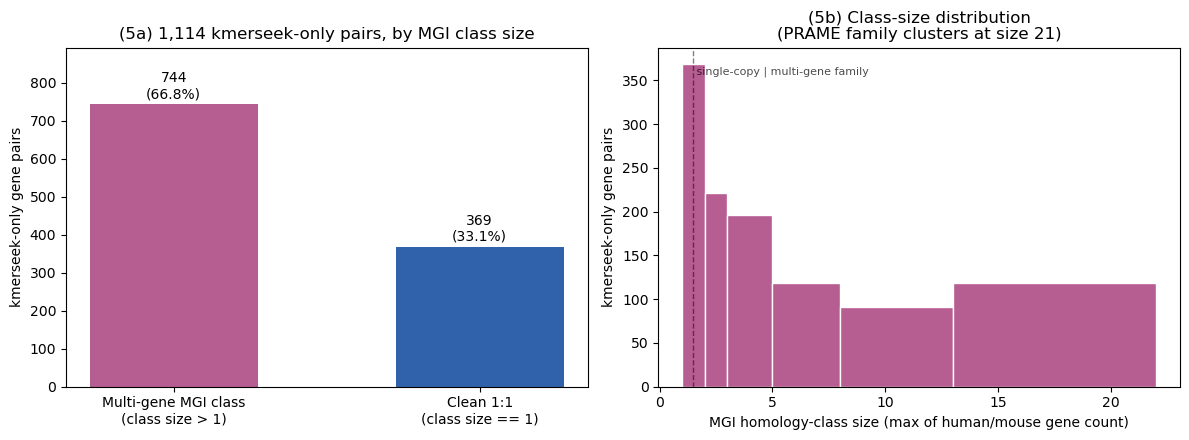

In [15]:
KO_ONLY_CSV = DATA_DIR / "120_kmerseek_only_pairs.csv"
HGNC_TXT = DATA_DIR / "hgnc_complete_set.txt"

# MGI homology-class size: how many human / mouse genes share the same DB Class Key
h_all = mgi_raw.filter(pl.col("NCBI Taxon ID") == 9606).select(["DB Class Key", "Symbol"]).rename({"Symbol": "human_gene"}).with_columns(pl.col("human_gene").str.to_uppercase())
m_all = mgi_raw.filter(pl.col("NCBI Taxon ID") == 10090).select(["DB Class Key", "Symbol"]).rename({"Symbol": "mouse_gene"}).with_columns(pl.col("mouse_gene").str.to_uppercase())
class_n_human = h_all.group_by("DB Class Key").agg(pl.col("human_gene").n_unique().alias("n_human_in_class"))
class_n_mouse = m_all.group_by("DB Class Key").agg(pl.col("mouse_gene").n_unique().alias("n_mouse_in_class"))
mouse_to_class: dict[str, set] = {}
for row in m_all.iter_rows(named=True):
    mouse_to_class.setdefault(row["mouse_gene"], set()).add(row["DB Class Key"])
class_size = {
    row["DB Class Key"]: (row["n_human_in_class"] or 0, row["n_mouse_in_class"] or 0)
    for row in class_n_human.join(class_n_mouse, on="DB Class Key", how="full", coalesce=True).iter_rows(named=True)
}

kmerseek_only = (
    pl.read_csv(KO_ONLY_CSV).select(["human_gene_name", "mouse_gene_name"]).unique()
    .with_columns([pl.col("human_gene_name").str.to_uppercase().alias("human_gene"),
                   pl.col("mouse_gene_name").str.to_uppercase().alias("mouse_gene")])
)
print(f"kmerseek-only pairs (MGI-true, OrthoFinder-missed): {kmerseek_only.height:,} unique gene pairs")

family_rows = []
for r in kmerseek_only.iter_rows(named=True):
    classes = mouse_to_class.get(r["mouse_gene"], set())
    n_h = max((class_size.get(c, (0, 0))[0] for c in classes), default=0)
    n_m = max((class_size.get(c, (0, 0))[1] for c in classes), default=0)
    family_rows.append(dict(human_gene=r["human_gene"], mouse_gene=r["mouse_gene"],
                             mgi_class_size=max(n_h, n_m)))
family_df = pl.DataFrame(family_rows)

n_expanded = int((family_df["mgi_class_size"] > 1).sum())
n_single = int((family_df["mgi_class_size"] == 1).sum())
n_total = family_df.height
print(f"\nIn an MGI multi-gene homology class (class size > 1): {n_expanded:,} / {n_total:,} ({n_expanded/n_total:.1%})")
print(f"Clean single-copy 1:1 MGI class (size == 1):          {n_single:,} / {n_total:,} ({n_single/n_total:.1%})")

hgnc = pl.read_csv(HGNC_TXT, separator="\t", infer_schema_length=50_000, null_values=[""])
sym2fam = dict(zip(
    hgnc.select("symbol").with_columns(pl.col("symbol").str.to_uppercase())["symbol"].to_list(),
    hgnc["gene_group"].to_list(),
))
big = family_df.filter(pl.col("mgi_class_size") >= 10).sort("mgi_class_size", descending=True)
print("\nExamples with MGI class size >= 10 (rapidly-duplicated families):")
for row in big.head(10).iter_rows(named=True):
    fam = sym2fam.get(row["human_gene"], "?")
    print(f"  {row['human_gene']:12s} vs {row['mouse_gene']:12s}  MGI_class_size={row['mgi_class_size']:3d}  HGNC_family={fam}")

# --- Figure: same finding, visualized ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))

axL.bar(["Multi-gene MGI class\n(class size > 1)", "Clean 1:1\n(class size == 1)"],
        [n_expanded, n_single], color=["#b65d91", "#3062ac"], width=0.55)
for i, v in enumerate([n_expanded, n_single]):
    axL.text(i, v + 15, f"{v:,}\n({v/n_total:.1%})", ha="center", fontsize=10)
axL.set_ylabel("kmerseek-only gene pairs")
axL.set_title(f"(5a) {n_total:,} kmerseek-only pairs, by MGI class size")
axL.set_ylim(0, max(n_expanded, n_single) * 1.2)

bins = [1, 2, 3, 5, 8, 13, 22]  # roughly matches the observed class-size distribution
axR.hist(family_df["mgi_class_size"].to_numpy(), bins=bins, color="#b65d91", edgecolor="white", align="mid")
axR.axvline(1.5, color="black", ls="--", alpha=0.5, lw=1)
axR.text(1.5, axR.get_ylim()[1] * 0.92, " single-copy | multi-gene family", fontsize=8, alpha=0.7)
axR.set_xlabel("MGI homology-class size (max of human/mouse gene count)")
axR.set_ylabel("kmerseek-only gene pairs")
axR.set_title("(5b) Class-size distribution\n(PRAME family clusters at size 21)")

plt.tight_layout()
plt.savefig(DATA_DIR / "200_kmerseek_only_family_size.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Verdict

**Updated 2026-08-05.** Section 3b's `roc_auc`/`auc_x_n`/`auc_x_logn` and `bits_per_kmer` are fully
populated (`200_alphabet_ksize_matched_scope_comparison.csv` and `200_hp_variants_full_sweep.csv`
both re-ran clean), and section 2b's 97-combo metric-leaderboard sweep completed.

**Ranking by F1.** Full 20-amino-acid protein at k=15 comes closest to OrthoFinder (F1=0.892,
gap≈0.005). Dayhoff k=20 is the strongest reduced alphabet (F1=0.872, gap≈0.015). Every HP variant
trails both, by at least 0.048.

**AUC ranks differently than F1.** Ranked by `roc_auc` (every candidate pair labeled, not just each
gene's RBH-selected best hit), protein k=6 wins at 0.994, a much shorter k than F1 prefers. RBH-F1
rewards a precise threshold call, one best hit per gene; AUC rewards the whole ranking being
well-ordered, which a shorter, less specific k-mer can achieve while still being too promiscuous to
trust as a single best-hit call. The two metrics answer different questions and disagree here.

**Bits, not k-size, is the fair axis, and HP still trails on it.** At matched bits (25-31, HP's
native k=18-30 range), protein k=6 (25.1 bits) reaches roc_auc=0.994 against the best HP variant at
the same budget, `hp_lehninger` k=25 (25.0 bits) at 0.988: protein leads by +0.006 AUC. Most of
HP's raw F1/AUC deficit is explained by the coarser alphabet; the residual gap at matched
information is ~0.006 AUC, far smaller than a k-size-only comparison implies.

**The best HP variant is `hp_pbotc_1st_ed`, not `hp_thomas_dill`.** Best F1 per HP variant, all at
their best k=30:

| encoding | best F1 (k=30) | gap to OrthoFinder |
|---|---|---|
| hp_pbotc_1st_ed | **0.8216** | 0.0477 |
| hp_lehninger (= plain hp) | 0.8121 | 0.0551 |
| hp_lehninger_plus_c | 0.8104 | 0.0557 |
| hp_thomas_dill | 0.8020 | 0.0625 |
| hp_kyte_doolittle | 0.7898 | 0.0742 |
| hp_thomas_dill_no_c | 0.7759 | 0.0865 |

`hp_pbotc_1st_ed` beats plain HP Lehninger by ~0.010 F1 and `hp_thomas_dill` by ~0.020 F1,
consistently across k=22-30 rather than only at k=30 (see the per-alphabet subplots and combined
plot above). It is also the best HP variant by raw AUC (0.992 at k=22, before bits-matching), so
this is not an F1-only artifact. `hp_thomas_dill` ranks 4th of 6, ahead of only kyte_doolittle and
its own no-c variant; its advantage (notebook 211) is specific to the MHC class I stress test, not
genome-wide.

**Ranking metric also depends on alphabet family** (section 2b). `jaccard` wins 65/78 HP-family
combos; `enr × containment / mean_matched_kmer_freq` wins 17/20 protein+dayhoff combos. HP's coarse
alphabet produces enough coincidental matches that the Poisson null stops discriminating, leaving
jaccard's normalization as the only score with signal. See section 2b for the breakdown.

**On beating OrthoFinder.** Kmerseek does not, once OrthoFinder is scored on a matched gene
universe. It comes close.

**What kmerseek adds.** Of the 1,114 pairs where kmerseek recovers an MGI-documented ortholog that
OrthoFinder's 1:1 clustering missed, roughly two-thirds sit inside a multi-gene MGI homology class
(PRAME, several zinc-finger subfamilies, MHC class I/H-2) — the regime where single-best-hit
clustering is expected to struggle and where containment-based search still lands a hit.

## 7. ROC curves and prediction-quality figures, per alphabet

Five figures per alphabet (the same 8 as section 3's subplots: protein, dayhoff, hp, and the 5
distinct HP variants; `hp_lehninger` is dropped as byte-identical to plain `hp`):

1. **ROC curve, one line per k-size.** Continuous jaccard ranking over every candidate
   (human_gene, mouse_gene) pair vs MGI truth, the same candidate universe as section 3b's
   `roc_auc`, colored by k-size.
2. **The same ROC curves colored by bits-per-kmer** instead of k-size, the fair axis for comparing
   alphabets of different symbol cardinality (section 6).
3. **Swarm plot of raw k-mer intersection count** (`n_intersecting_hashes`) at that alphabet's
   best-F1 k-size, split by RBH call ("Homolog Prediction") on x and MGI truth ("Known Homolog") by
   color. Precision/recall are printed per column, each column scored as its own class: "True" is
   precision/recall on the RBH-called set (the `kmerseek_precision`/`kmerseek_recall` numbers from
   section 3), "False" is negative predictive value/specificity on everything RBH did not call.
   Precision/recall are computed on the full candidate-pair data; only the plotted points are
   subsampled, since non-RBH candidates far outnumber RBH calls. A 2x2 truth table (TP/FP/FN/TN
   counts) is drawn under each panel, since the "True"/"False" precision/recall pair above is
   easy to misread as a confusion matrix on its own.
4. **2x2 Venn diagram of RBH call vs MGI truth**, one panel per alphabet, same best-F1 k-size.
   Same TP/FP/FN as the truth table, drawn as circle overlap instead of a grid; TN (neither set)
   isn't a venn region, so it's printed under each panel instead. Colors match section 8's
   set-identity convention: kmerseek blue, MGI aqua.
5. **UpSet plot of the same RBH call / MGI truth combination**, one per alphabet -- a second
   reading of the identical four counts as a dot-matrix + bar chart, useful because venn circle
   area is not proportional to count once TP/FP/FN are orders of magnitude below TN.

In [16]:
# Encoding label (as used in sweep_df_ext/section 3/section 6) -> dash-named file/cache key.
# The 5 genuinely-distinct HP variants have dash-named raw results files and pair_cache entries
# (human_vs_mouse.hp-thomas-dill.k30..., pair_cache/hp-thomas-dill_k30_jaccard.parquet) -- same
# naming quirk as HP_VARIANT_DASH_TO_LABEL in the imports cell, just inverted. "protein",
# "dayhoff", "hp" pass through unchanged (single-word, no dash/underscore split).
LABEL_TO_DASH = {label: dash for dash, label in HP_VARIANT_DASH_TO_LABEL.items()}

def file_encoding(enc: str) -> str:
    return LABEL_TO_DASH.get(enc, enc)

def ksizes_for(enc: str) -> range:
    return ALPHABET_KSIZES[enc] if enc in ALPHABET_KSIZES else HP_VARIANT_KSIZES

roc_curves = {}  # (encoding, ksize) -> (fpr, tpr, roc_auc)
for enc in ENCODINGS:
    for k in ksizes_for(enc):
        result = ou.roc_curve_for_combo(file_encoding(enc), k, mgi_pairs, DATA_DIR)
        if result is not None:
            roc_curves[(enc, k)] = result

print(f"Built ROC curves for {len(roc_curves)} alphabet/ksize combos across {len(ENCODINGS)} alphabets")


Built ROC curves for 88 alphabet/ksize combos across 8 alphabets


encoding,ksize,roc_auc
str,i64,f64
"""dayhoff""",10,0.993061
"""dayhoff""",11,0.992778
"""dayhoff""",12,0.991501
"""dayhoff""",13,0.98982
"""dayhoff""",14,0.986226
…,…,…
"""protein""",11,0.960021
"""protein""",12,0.958026
"""protein""",13,0.951658


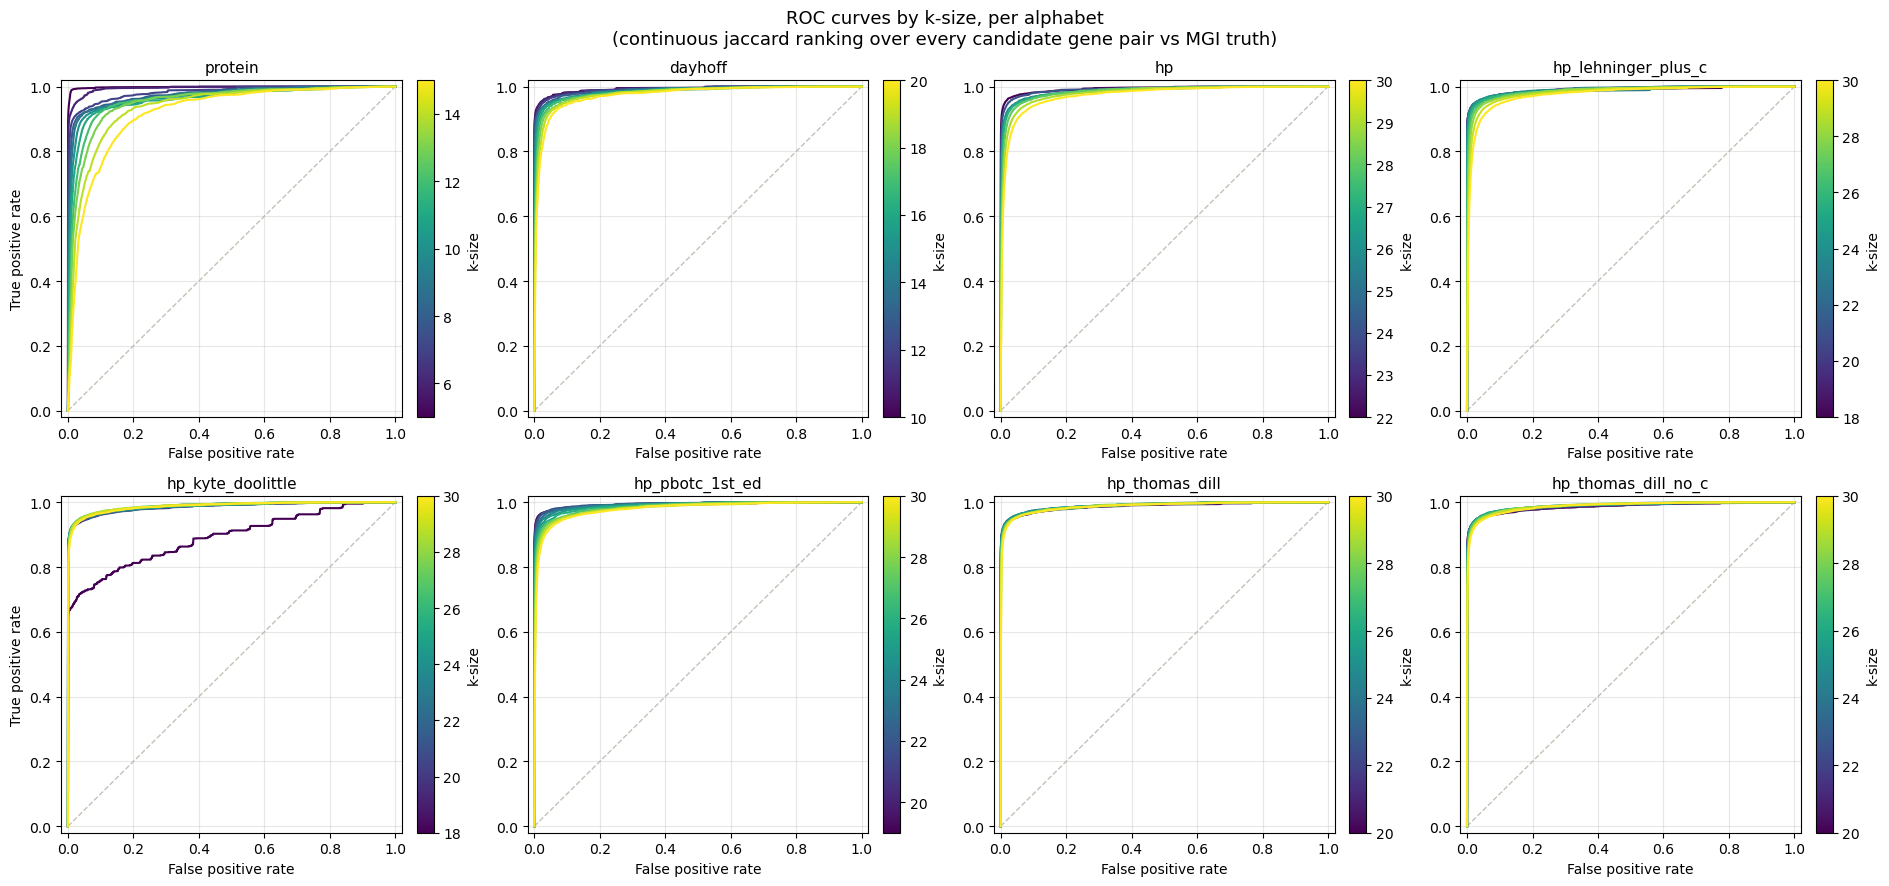

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9))
roc_auc_rows = []
for ax, enc in zip(axes.flat, ENCODINGS):
    ks = sorted(k for k in ksizes_for(enc) if (enc, k) in roc_curves)
    if not ks:
        ax.set_visible(False)
        continue
    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=min(ks), vmax=max(ks))
    for k in ks:
        fpr, tpr, auc = roc_curves[(enc, k)]
        ax.plot(fpr, tpr, color=cmap(norm(k)), lw=1.5)
        roc_auc_rows.append({"encoding": enc, "ksize": k, "roc_auc": auc})
    ax.plot([0, 1], [0, 1], "--", color="#c3c2b7", lw=1, zorder=0)
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("False positive rate")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, label="k-size", fraction=0.046, pad=0.04)
for ax in axes[:, 0]:
    ax.set_ylabel("True positive rate")
fig.suptitle("ROC curves by k-size, per alphabet\n(continuous jaccard ranking over every candidate gene pair vs MGI truth)", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_roc_curves_by_ksize.png", dpi=150, bbox_inches="tight")

roc_auc_df = pl.DataFrame(roc_auc_rows).sort(["encoding", "ksize"])
roc_auc_df


encoding,ksize,bits_per_kmer,roc_auc
str,i64,f64,f64
"""dayhoff""",10,22.780009,0.993061
"""dayhoff""",11,25.05801,0.992778
"""dayhoff""",12,27.336011,0.991501
"""dayhoff""",13,29.614012,0.98982
"""dayhoff""",14,31.892013,0.986226
…,…,…,…
"""protein""",11,45.939719,0.960021
"""protein""",12,50.116057,0.958026
"""protein""",13,54.292395,0.951658


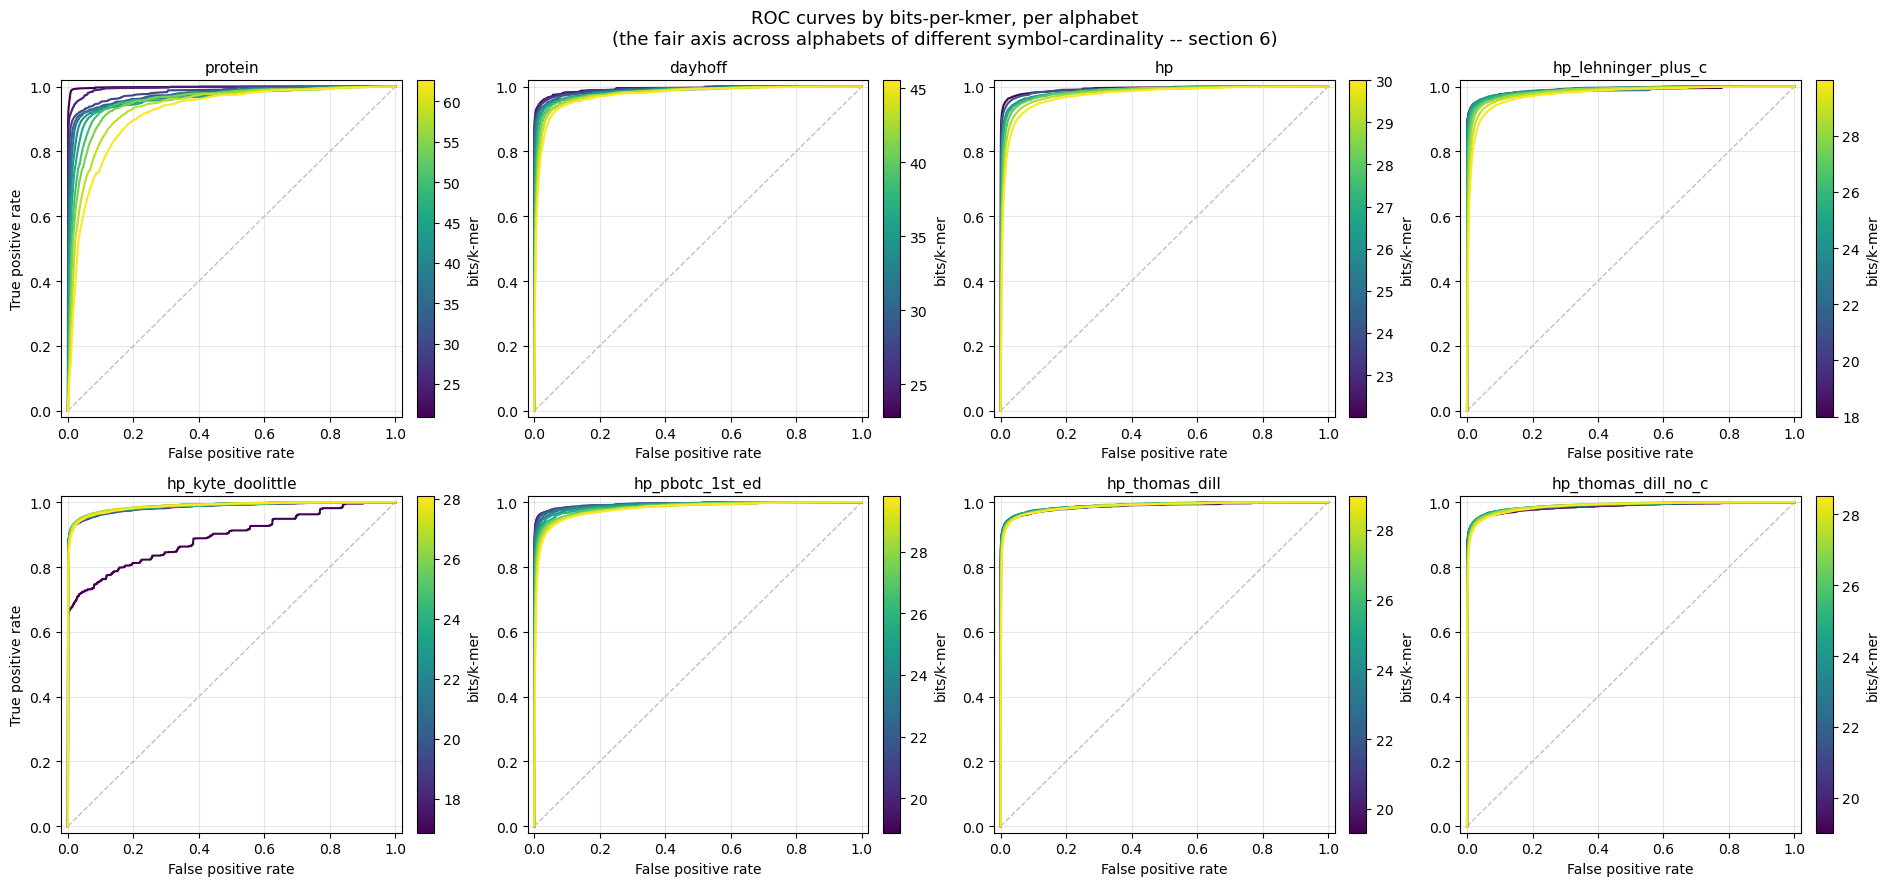

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(19, 9))
bits_rows = []
for ax, enc in zip(axes.flat, ENCODINGS):
    ks = sorted(k for k in ksizes_for(enc) if (enc, k) in roc_curves)
    if not ks:
        ax.set_visible(False)
        continue
    bits = {k: ou.bits_per_kmer(enc, k) for k in ks}
    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=min(bits.values()), vmax=max(bits.values()))
    for k in ks:
        fpr, tpr, auc = roc_curves[(enc, k)]
        ax.plot(fpr, tpr, color=cmap(norm(bits[k])), lw=1.5)
        bits_rows.append({"encoding": enc, "ksize": k, "bits_per_kmer": bits[k], "roc_auc": auc})
    ax.plot([0, 1], [0, 1], "--", color="#c3c2b7", lw=1, zorder=0)
    ax.set_title(enc, fontsize=11)
    ax.set_xlabel("False positive rate")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, label="bits/k-mer", fraction=0.046, pad=0.04)
for ax in axes[:, 0]:
    ax.set_ylabel("True positive rate")
fig.suptitle("ROC curves by bits-per-kmer, per alphabet\n(the fair axis across alphabets of different symbol-cardinality -- section 6)", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "200_roc_curves_by_bits.png", dpi=150, bbox_inches="tight")

bits_df = pl.DataFrame(bits_rows).sort(["encoding", "ksize"])
bits_df


In [19]:
best_k_per_alphabet = {
    enc: sweep_df_ext.filter(pl.col("encoding") == enc).sort("kmerseek_F1", descending=True)["ksize"][0]
    for enc in ENCODINGS
}
print("Best-F1 k-size per alphabet:", best_k_per_alphabet)

def swarm_data_for_combo(enc: str, k: int) -> pl.DataFrame:
    """One row per candidate (human_gene, mouse_gene) pair at this combo's best k:
    n_intersecting_hashes, MGI truth ("is_known_homolog"), and RBH call ("is_rbh") -- the
    panel-B swarm input. RBH selection still uses jaccard (same rule as everywhere else in this
    notebook); n_intersecting_hashes here is only the DISPLAYED metric, joined in separately
    (see ou.load_intersecting_hashes)."""
    fenc = file_encoding(enc)
    jac = ou.load_pair_table(fenc, k, DATA_DIR)
    hashes = ou.load_intersecting_hashes(fenc, k, DATA_DIR)
    rbh_set, scope = ou.rbh_pairs_and_scope(fenc, k, DATA_DIR)
    mgi_scope = mgi_pairs.filter(pl.col("human_gene").is_in(list(scope)))
    mgi_scope_set = set(zip(mgi_scope["human_gene"].to_list(), mgi_scope["mouse_gene"].to_list()))

    df = jac.join(hashes, on=["human_gene", "mouse_gene"], how="inner")
    pairs = list(zip(df["human_gene"].to_list(), df["mouse_gene"].to_list()))
    return df.with_columns([
        pl.Series("is_rbh", [p in rbh_set for p in pairs]),
        pl.Series("is_known_homolog", [p in mgi_scope_set for p in pairs]),
    ])

# Precision/recall for the "True" column use ou.prf1 on the FULL rbh_set/mgi_scope_set (matching
# section 3's kmerseek_precision/kmerseek_recall exactly), not sklearn on the swarm dataframe --
# a candidate pair only exists in that dataframe if it shares >=1 k-mer, so a true MGI ortholog
# with ZERO shared k-mers (a real false negative) would otherwise silently vanish from the count
# instead of dragging recall down. "False" column precision/recall (NPV/specificity) reuse the
# same TP/FP/FN and add TN from the swarm dataframe (every candidate pair is observable, so TN
# needs no such correction).
swarm_data = {}
swarm_stats = []
for enc in ENCODINGS:
    k = best_k_per_alphabet[enc]
    df = swarm_data_for_combo(enc, k)
    swarm_data[enc] = df

    fenc = file_encoding(enc)
    rbh_set, scope = ou.rbh_pairs_and_scope(fenc, k, DATA_DIR)
    mgi_scope = mgi_pairs.filter(pl.col("human_gene").is_in(list(scope)))
    mgi_scope_set = set(zip(mgi_scope["human_gene"].to_list(), mgi_scope["mouse_gene"].to_list()))
    p_true, r_true, f1_true, tp, fp, fn = ou.prf1(rbh_set, mgi_scope_set)
    tn = df.filter(~pl.col("is_rbh") & ~pl.col("is_known_homolog")).height
    p_false = tn / (tn + fn) if (tn + fn) else 0.0
    r_false = tn / (tn + fp) if (tn + fp) else 0.0

    swarm_stats.append({
        "encoding": enc, "ksize": k, "n_candidate_pairs": df.height,
        "n_rbh_calls": len(rbh_set), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision_false": p_false, "recall_false": r_false,
        "precision_true": p_true, "recall_true": r_true,
    })

swarm_stats_df = pl.DataFrame(swarm_stats)
swarm_stats_df


Best-F1 k-size per alphabet: {'protein': 15, 'dayhoff': 20, 'hp': 30, 'hp_lehninger_plus_c': 30, 'hp_kyte_doolittle': 16, 'hp_pbotc_1st_ed': 30, 'hp_thomas_dill': 30, 'hp_thomas_dill_no_c': 20}


encoding,ksize,n_candidate_pairs,n_rbh_calls,tp,fp,fn,tn,precision_false,recall_false,precision_true,recall_true
str,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64
"""protein""",15,57913,15805,15391,414,3224,40145,0.925661,0.989793,0.973806,0.826806
"""dayhoff""",20,259437,15886,15389,497,3941,241387,0.983936,0.997945,0.968715,0.79612
"""hp""",30,254598,15616,15048,568,6221,236808,0.974402,0.997607,0.963627,0.707509
"""hp_lehninger_plus_c""",30,300583,15578,14989,589,6169,282843,0.978655,0.997922,0.96219,0.708432
"""hp_kyte_doolittle""",16,322923,72,64,8,12,322842,0.999963,0.999975,0.888889,0.842105
"""hp_pbotc_1st_ed""",30,435064,15699,15124,575,5821,417117,0.986237,0.998623,0.963373,0.722082
"""hp_thomas_dill""",30,1716389,15643,15035,608,6424,1698286,0.996232,0.999642,0.961133,0.700638
"""hp_thomas_dill_no_c""",20,42635070,15940,15310,630,6780,42615265,0.999841,0.999985,0.960477,0.693074


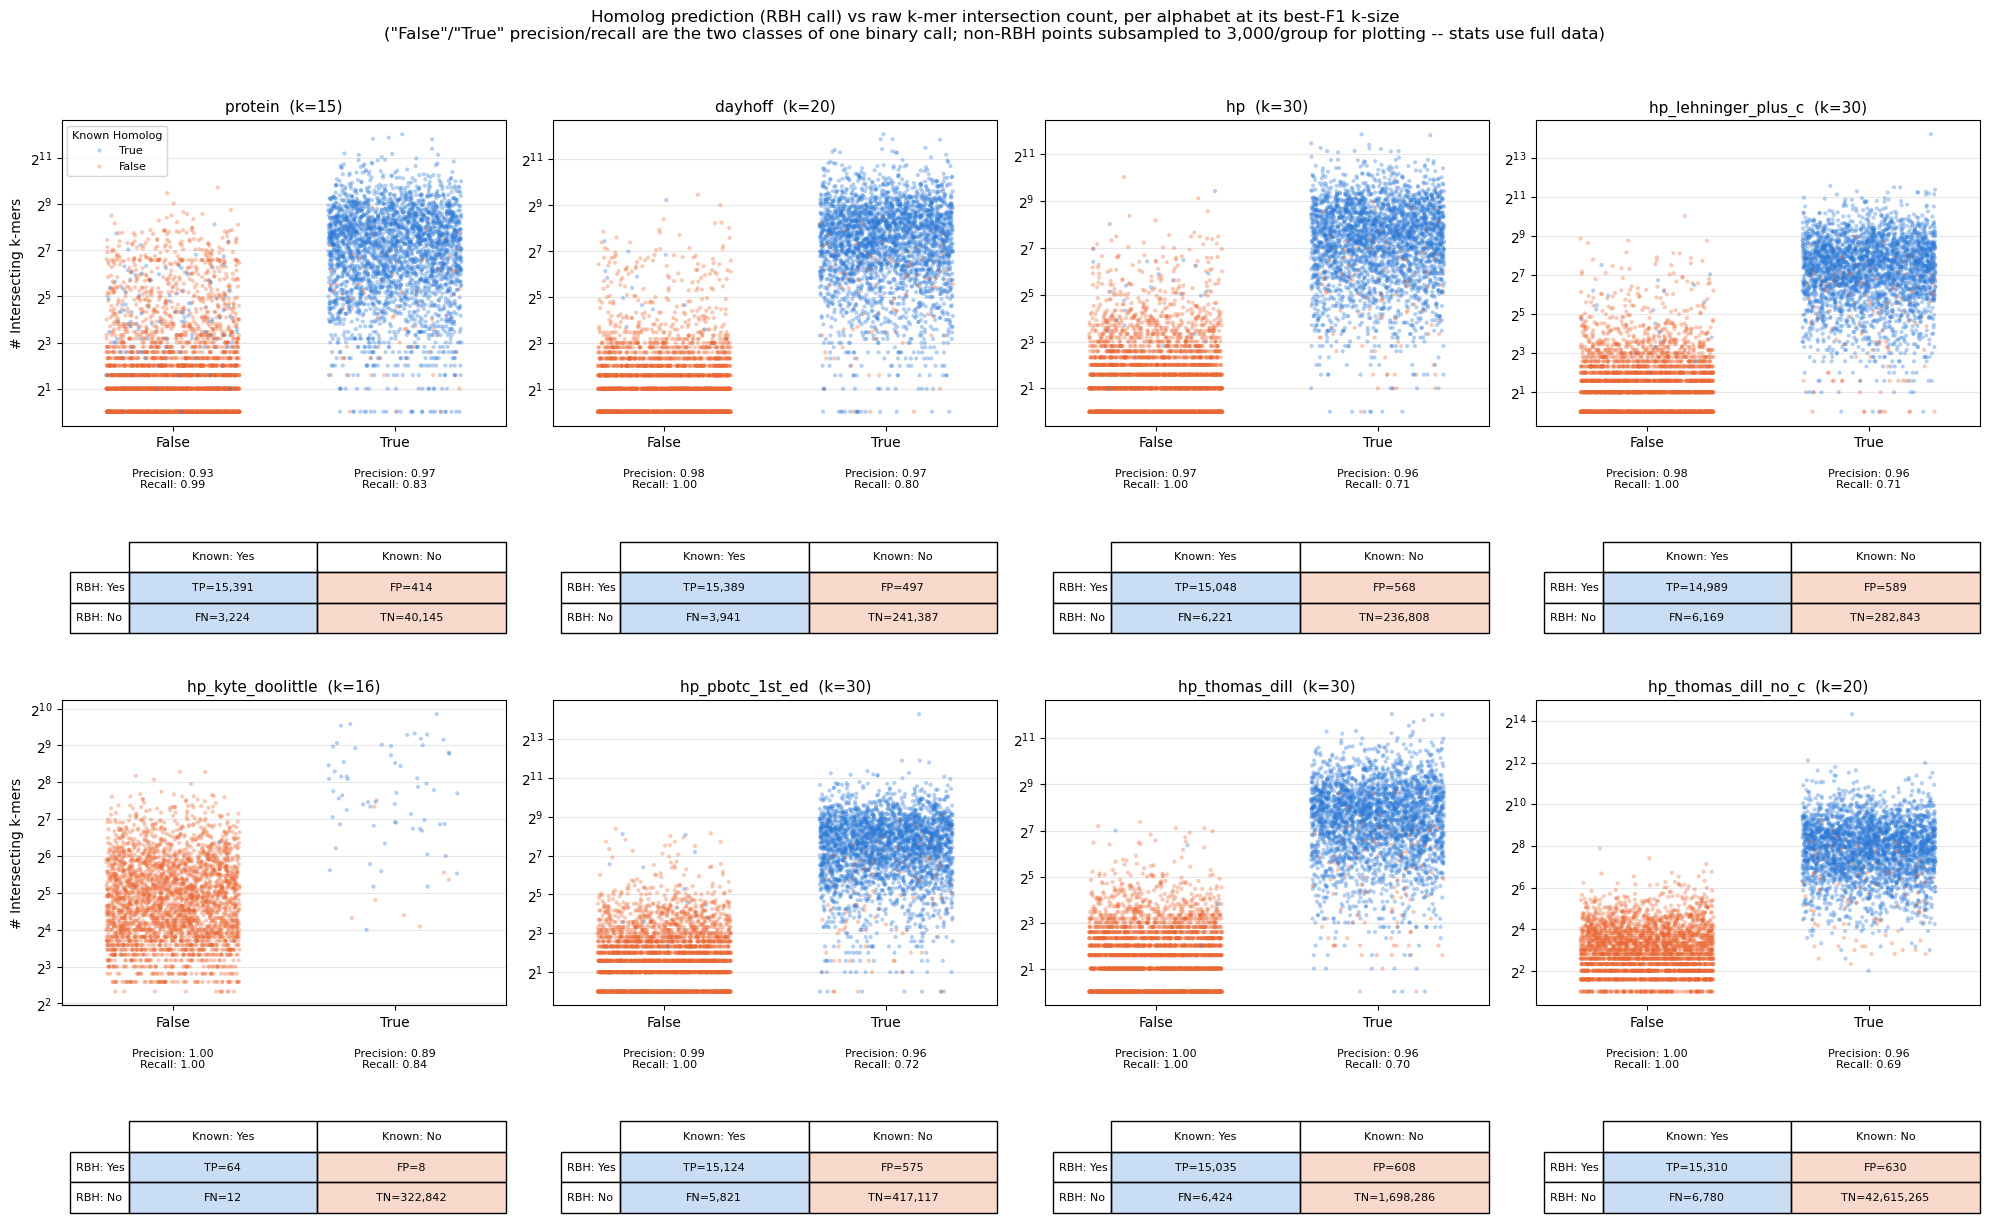

In [20]:
import seaborn as sns
from matplotlib.colors import to_rgba

KNOWN_HOMOLOG_COLORS = {"True": "#2a78d6", "False": "#eb6834"}
TRUTH_TABLE_TINT = {k: to_rgba(v, alpha=0.25) for k, v in KNOWN_HOMOLOG_COLORS.items()}
RNG = np.random.default_rng(0)
MAX_POINTS_PER_GROUP = 3000

def subsample(df: pl.DataFrame, n: int) -> pl.DataFrame:
    if df.height <= n:
        return df
    idx = RNG.choice(df.height, size=n, replace=False)
    return df[idx.tolist()]

fig, axes = plt.subplots(2, 4, figsize=(20, 14))
for i, (ax, enc) in enumerate(zip(axes.flat, ENCODINGS)):
    df = swarm_data[enc]
    stat = swarm_stats_df.filter(pl.col("encoding") == enc).to_dicts()[0]

    plot_df = pl.concat([
        subsample(df.filter(pl.col("is_rbh")), MAX_POINTS_PER_GROUP),
        subsample(df.filter(~pl.col("is_rbh")), MAX_POINTS_PER_GROUP),
    ]).to_pandas()
    plot_df["Homolog Prediction"] = plot_df["is_rbh"].map({True: "True", False: "False"})
    plot_df["Known Homolog"] = plot_df["is_known_homolog"].map({True: "True", False: "False"})

    sns.stripplot(
        data=plot_df, x="Homolog Prediction", y="n_intersecting_hashes", hue="Known Homolog",
        order=["False", "True"], hue_order=["True", "False"], palette=KNOWN_HOMOLOG_COLORS,
        alpha=0.35, size=3, jitter=0.3, ax=ax, legend=(i == 0),
    )
    ax.set_yscale("log", base=2)
    ax.set_title(f"{enc}  (k={stat['ksize']})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("# Intersecting k-mers" if i % 4 == 0 else "")
    ax.grid(True, alpha=0.3, axis="y")
    ax.text(0.25, -0.14, f"Precision: {stat['precision_false']:.2f}\nRecall: {stat['recall_false']:.2f}",
            transform=ax.transAxes, ha="center", va="top", fontsize=8)
    ax.text(0.75, -0.14, f"Precision: {stat['precision_true']:.2f}\nRecall: {stat['recall_true']:.2f}",
            transform=ax.transAxes, ha="center", va="top", fontsize=8)
    if i == 0:
        ax.legend(title="Known Homolog", fontsize=8, title_fontsize=8, loc="upper left")

    # Truth table: which quadrant is TP/FP/FN/TN, spelled out literally since the swarm
    # above only distinguishes them by (x position, point color).
    tbl = ax.table(
        cellText=[[f"TP={stat['tp']:,}", f"FP={stat['fp']:,}"],
                  [f"FN={stat['fn']:,}", f"TN={stat['tn']:,}"]],
        rowLabels=["RBH: Yes", "RBH: No"],
        colLabels=["Known: Yes", "Known: No"],
        cellColours=[[TRUTH_TABLE_TINT["True"], TRUTH_TABLE_TINT["False"]],
                     [TRUTH_TABLE_TINT["True"], TRUTH_TABLE_TINT["False"]]],
        cellLoc="center",
        bbox=[0.15, -0.68, 0.85, 0.3],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)

fig.suptitle(
    "Homolog prediction (RBH call) vs raw k-mer intersection count, per alphabet at its best-F1 k-size\n"
    f"(\"False\"/\"True\" precision/recall are the two classes of one binary call; "
    f"non-RBH points subsampled to {MAX_POINTS_PER_GROUP:,}/group for plotting -- stats use full data)",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.subplots_adjust(hspace=0.9)
plt.savefig(DATA_DIR / "200_swarm_precision_recall_per_alphabet.png", dpi=150, bbox_inches="tight")


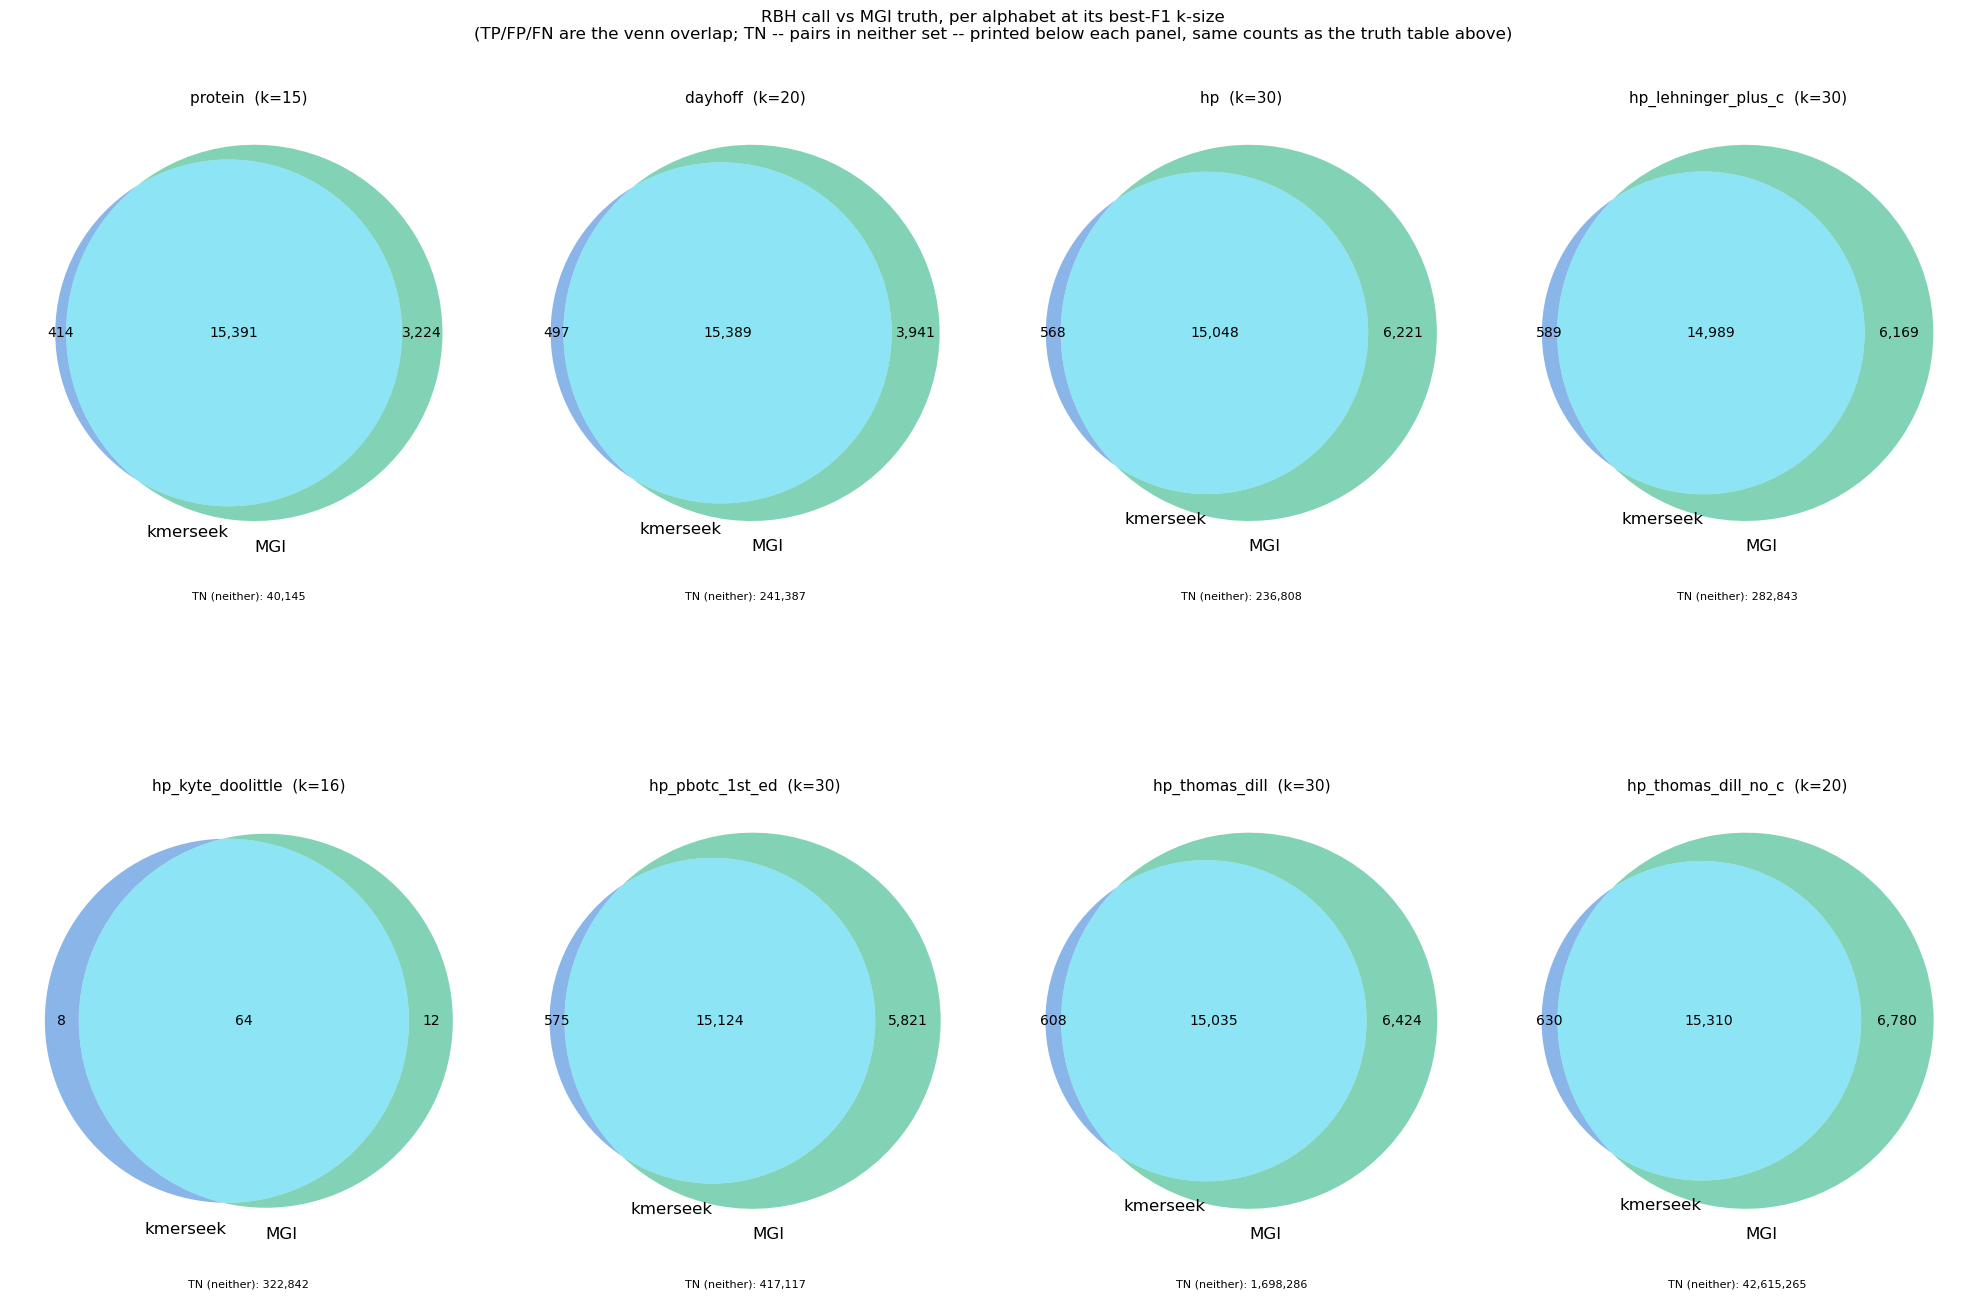

In [21]:
from matplotlib_venn import venn2

# Same set-identity colors as section 8's three-way Venn: kmerseek blue, MGI aqua.
VENN2_COLORS = ("#2a78d6", "#1baf7a")

fig, axes = plt.subplots(2, 4, figsize=(20, 13))
for i, (ax, enc) in enumerate(zip(axes.flat, ENCODINGS)):
    stat = swarm_stats_df.filter(pl.col("encoding") == enc).to_dicts()[0]
    tp, fp, fn, tn = stat["tp"], stat["fp"], stat["fn"], stat["tn"]
    venn2(
        subsets=(fp, fn, tp), set_labels=("kmerseek", "MGI"), set_colors=VENN2_COLORS,
        alpha=0.55, ax=ax, subset_label_formatter=lambda x: f"{int(x):,}",
    )
    ax.set_title(f"{enc}  (k={stat['ksize']})", fontsize=11)
    ax.text(0.5, -0.1, f"TN (neither): {tn:,}", transform=ax.transAxes, ha="center", fontsize=8)

fig.suptitle(
    "RBH call vs MGI truth, per alphabet at its best-F1 k-size\n"
    "(TP/FP/FN are the venn overlap; TN -- pairs in neither set -- printed below each panel, "
    "same counts as the truth table above)",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0.02, 1, 0.95])
fig.subplots_adjust(hspace=0.55)
plt.savefig(DATA_DIR / "200_venn_rbh_vs_mgi_per_alphabet.png", dpi=150, bbox_inches="tight")


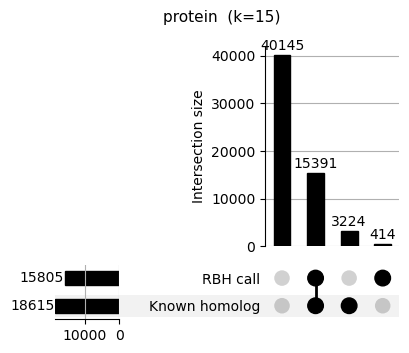

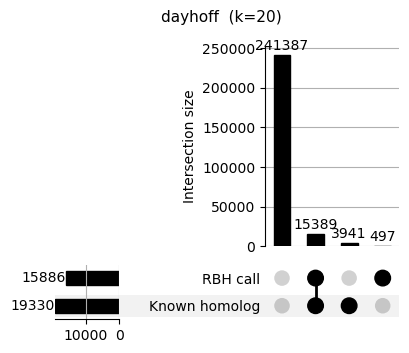

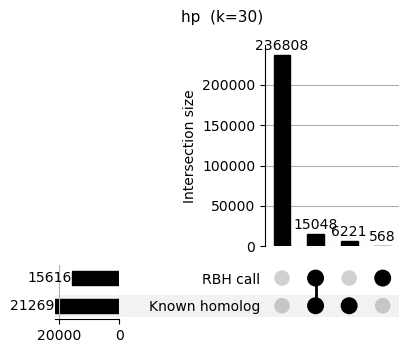

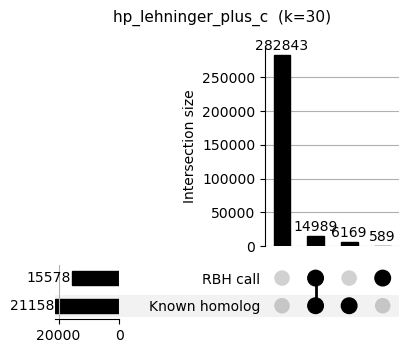

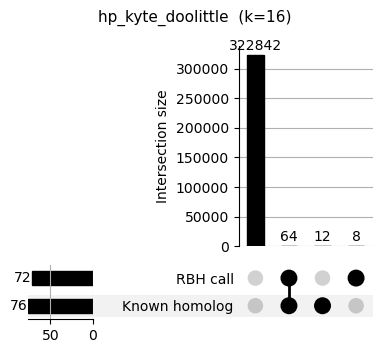

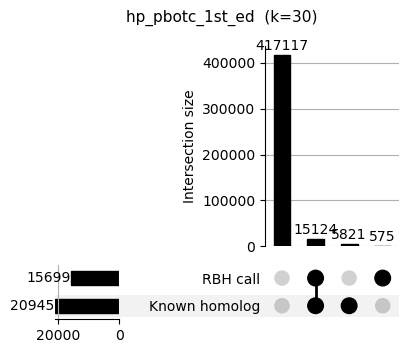

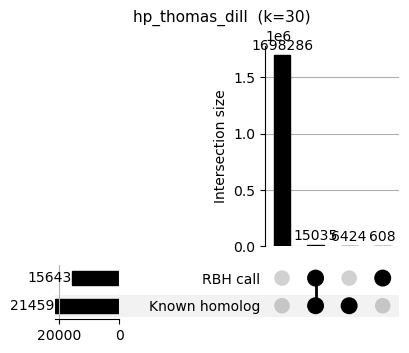

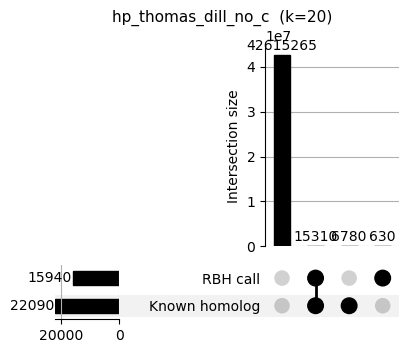

In [22]:
import pandas as pd

import upsetplot

# pandas>=3.0 permanently enables copy-on-write, which silently no-ops upsetplot 0.9.0's
# chained `styles["col"].fillna(..., inplace=True)` calls in plot_matrix, leaving NaN
# facecolors that matplotlib then rejects. Patch with the same body, non-chained.
def _patched_plot_matrix(self, ax):
    ax = self._reorient(ax)
    data = self.intersections
    n_cats = data.index.nlevels
    inclusion = data.index.to_frame().values
    styles = [
        [
            self.subset_styles[i] if inclusion[i, j] else {"facecolor": self._other_dots_color, "linewidth": 0}
            for j in range(n_cats)
        ]
        for i in range(len(data))
    ]
    styles = sum(styles, [])
    style_columns = {
        "facecolor": "facecolors", "edgecolor": "edgecolors",
        "linewidth": "linewidths", "linestyle": "linestyles", "hatch": "hatch",
    }
    styles = (
        pd.DataFrame(styles).reindex(columns=style_columns.keys())
        .astype({"facecolor": "O", "edgecolor": "O", "linewidth": float, "linestyle": "O", "hatch": "O"})
    )
    styles["linewidth"] = styles["linewidth"].fillna(1)
    styles["facecolor"] = styles["facecolor"].fillna(self._facecolor)
    styles["edgecolor"] = styles["edgecolor"].fillna(styles["facecolor"])
    styles["linestyle"] = styles["linestyle"].fillna("solid")
    del styles["hatch"]
    x = np.repeat(np.arange(len(data)), n_cats)
    y = np.tile(np.arange(n_cats), len(data))
    s = (self._element_size * 0.35) ** 2 if self._element_size is not None else 200
    ax.scatter(*self._swapaxes(x, y), s=s, zorder=10, **styles.rename(columns=style_columns))
    if self._with_lines:
        idx = np.flatnonzero(inclusion)
        line_data = pd.Series(y[idx], index=x[idx]).groupby(level=0).aggregate(["min", "max"])
        colors = pd.Series(
            [style.get("edgecolor", style.get("facecolor", self._facecolor)) for style in self.subset_styles],
            name="color",
        )
        line_data = line_data.join(colors)
        ax.vlines(line_data.index.values, line_data["min"], line_data["max"], lw=2, colors=line_data["color"], zorder=5)
    tick_axis = ax.yaxis
    tick_axis.set_ticks(np.arange(n_cats))
    tick_axis.set_ticklabels(data.index.names, rotation=0 if self._horizontal else -90)
    ax.xaxis.set_visible(False)
    ax.tick_params(axis="both", which="both", length=0)
    if not self._horizontal:
        ax.yaxis.set_ticks_position("top")
    ax.set_frame_on(False)
    ax.set_xlim(-0.5, x[-1] + 0.5, auto=False)
    ax.grid(False)

upsetplot.UpSet.plot_matrix = _patched_plot_matrix

for i, enc in enumerate(ENCODINGS):
    stat = swarm_stats_df.filter(pl.col("encoding") == enc).to_dicts()[0]
    tp, fp, fn, tn = stat["tp"], stat["fp"], stat["fn"], stat["tn"]
    idx = pd.MultiIndex.from_tuples(
        [(True, True), (True, False), (False, True), (False, False)],
        names=["RBH call", "Known homolog"],
    )
    counts = pd.Series([tp, fp, fn, tn], index=idx)

    fig = plt.figure(figsize=(6, 4))
    us = upsetplot.UpSet(counts, subset_size="sum", show_counts=True, sort_by="cardinality")
    us.plot(fig=fig)
    fig.suptitle(f"{enc}  (k={stat['ksize']})", fontsize=11)
    plt.savefig(DATA_DIR / f"200_upset_rbh_vs_mgi_{enc}.png", dpi=150, bbox_inches="tight")


## 8. Three-way overlap: MGI vs OrthoFinder vs kmerseek

Both kmerseek and OrthoFinder run on the same GENCODE build as the rest of this notebook (human
v49, mouse vM38, canonical protein translations), so gene identity is comparable across all three
sets.

Six alphabet/k-size combos, each a 3-way Venn of `(human_gene, mouse_gene)` ortholog-pair sets:
**MGI** (ground truth), **OrthoFinder** (sequence-similarity baseline), and **kmerseek** (this
combo's RBH call, `ou.rbh_pairs_and_scope`, the same rule as sections 2-3). Top row is each
alphabet's best genome-wide combo (section 6: `hp_pbotc_1st_ed` k=30, `protein` k=15, `dayhoff`
k=20). Bottom row is each alphabet's best MHC combo (notebook 211: `hp_pbotc_1st_ed` k=19,
`protein` k=6, `dayhoff` k=12), with all three sets restricted to the 22 MHC-proper genes
(`ou.MHC_CLASSES`, excluding `TAP1`/`TAP2`/`TAPBP`, which are antigen-processing controls rather
than MHC molecules).

**The MHC row does not reproduce notebook 211's number.** 211 builds no explicit "called" pair set:
its verdict is a continuous containment ranking scored by ROC-AUC/recovery, and its pair table has
no OrthoFinder column. The MHC panels here reuse the genome-wide RBH call from the top row (all
~19-20k mouse genes as candidates, as in sections 2-3), then restrict the three sets to MHC-proper
human genes for display.

In [23]:
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

# MHC-proper genes: the 25-gene human MHC query set (ou.MHC_CLASSES) minus the three
# antigen-processing controls (TAP1/TAP2/TAPBP), which support presentation but aren't MHC
# molecules themselves.
MHC_GENES = {g for g, cls in ou.MHC_CLASSES.items() if cls != "processing (ctrl)"}

VENN_COMBOS = [
    ("hp-pbotc-1st-ed", 30, "hp_pbotc_1st_ed k=30", "genome-wide best HP", None),
    ("protein", 15, "protein k=15", "genome-wide best protein", None),
    ("dayhoff", 20, "dayhoff k=20", "genome-wide best dayhoff", None),
    ("hp-pbotc-1st-ed", 19, "hp_pbotc_1st_ed k=19", "MHC best HP", MHC_GENES),
    ("protein", 6, "protein k=6", "MHC best protein", MHC_GENES),
    ("dayhoff", 12, "dayhoff k=12", "MHC best dayhoff", MHC_GENES),
]

def venn_sets_for_combo(dash_encoding: str, ksize: int, gene_filter: set[str] | None = None) -> dict:
    """kmerseek (RBH), MGI, and OrthoFinder pair sets, all re-scored on the SAME human-gene
    scope this combo's file covers (notebook 200, lesson 2) -- then optionally restricted to
    `gene_filter` (MHC-proper genes) for display, on the human-gene side only."""
    rbh_set, scope = ou.rbh_pairs_and_scope(dash_encoding, ksize, DATA_DIR)
    mgi_scoped = mgi_pairs.filter(pl.col("human_gene").is_in(list(scope)))
    mgi_set = set(zip(mgi_scoped["human_gene"].to_list(), mgi_scoped["mouse_gene"].to_list()))
    of_set = {(hg, mg) for (hg, mg) in of_set_all if hg in scope}
    if gene_filter is not None:
        rbh_set = {(hg, mg) for hg, mg in rbh_set if hg in gene_filter}
        mgi_set = {(hg, mg) for hg, mg in mgi_set if hg in gene_filter}
        of_set = {(hg, mg) for hg, mg in of_set if hg in gene_filter}
    return dict(kmerseek=rbh_set, mgi=mgi_set, orthofinder=of_set, n_genes_scope=len(scope))

venn_data = []
for dash_enc, k, label, row_label, gene_filter in VENN_COMBOS:
    sets = venn_sets_for_combo(dash_enc, k, gene_filter)
    venn_data.append(dict(label=label, row_label=row_label, **sets))

venn_summary = pl.DataFrame([
    dict(combo=d["label"], row=d["row_label"], n_genes_scope=d["n_genes_scope"],
         kmerseek=len(d["kmerseek"]), mgi=len(d["mgi"]), orthofinder=len(d["orthofinder"]),
         all_three=len(d["kmerseek"] & d["mgi"] & d["orthofinder"]))
    for d in venn_data
])
venn_summary


combo,row,n_genes_scope,kmerseek,mgi,orthofinder,all_three
str,str,i64,i64,i64,i64,i64
"""hp_pbotc_1st_ed k=30""","""genome-wide best HP""",18982,15699,20945,20804,14963
"""protein k=15""","""genome-wide best protein""",17328,15805,18615,19291,15256
"""dayhoff k=20""","""genome-wide best dayhoff""",17772,15886,19330,19718,15206
"""hp_pbotc_1st_ed k=19""","""MHC best HP""",19697,12,94,16,7
"""protein k=6""","""MHC best protein""",19702,10,94,16,8
"""dayhoff k=12""","""MHC best dayhoff""",19677,10,94,16,7


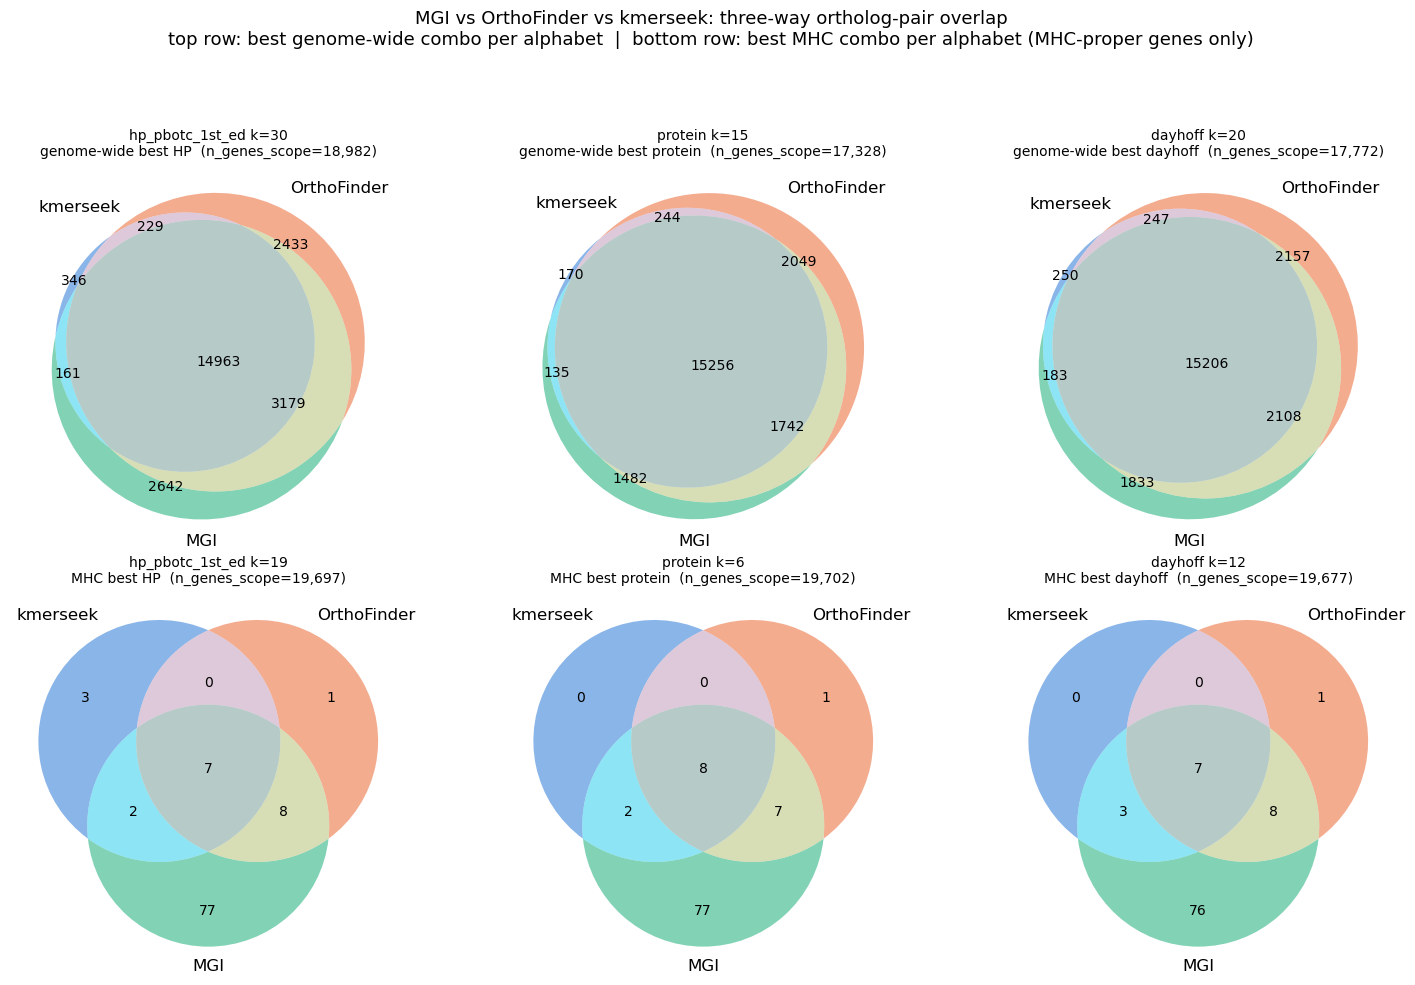

In [24]:
# Categorical colors follow entity identity (kmerseek / OrthoFinder / MGI), fixed across all six
# panels -- dataviz palette slots 1-3 (blue/orange/aqua), validated all-pairs CVD-safe.
VENN_COLORS = ("#2a78d6", "#eb6834", "#1baf7a")  # kmerseek, OrthoFinder, MGI
VENN_SET_LABELS = ("kmerseek", "OrthoFinder", "MGI")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, d in zip(axes.flat, venn_data):
    subsets = (d["kmerseek"], d["orthofinder"], d["mgi"])
    # Area-weighted for the genome-wide row (thousands of pairs, proportions are informative);
    # equal-circle layout for the MHC row (tens of pairs -- a weighted layout would collapse the
    # smallest circle to near-invisible).
    layout = (DefaultLayoutAlgorithm(fixed_subset_sizes=(1,) * 7)
              if d["row_label"].startswith("MHC") else None)
    venn3(subsets, set_labels=VENN_SET_LABELS, set_colors=VENN_COLORS, alpha=0.55, ax=ax,
          layout_algorithm=layout)
    ax.set_title(f"{d['label']}\n{d['row_label']}  (n_genes_scope={d['n_genes_scope']:,})", fontsize=10)

fig.suptitle(
    "MGI vs OrthoFinder vs kmerseek: three-way ortholog-pair overlap\n"
    "top row: best genome-wide combo per alphabet  |  bottom row: best MHC combo per alphabet (MHC-proper genes only)",
    fontsize=13,
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(DATA_DIR / "200_venn_mgi_orthofinder_kmerseek.png", dpi=150, bbox_inches="tight")
